# Re-enacting DiffAD with Rectified Flow

Install dependencies & imports

In [1]:
# Cell 0: Compatibility fix
!pip install -q scipy==1.11.4
# torch.compile
!pip install triton -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 53.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.11.4 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.2 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.2.2 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1

In [2]:
# Cell 1: Install and import everything
!pip install -q kagglehub diffusers imgaug

# ============================================================================
# Environment Configuration
# ============================================================================
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ============================================================================
# Standard Python Libraries
# ============================================================================
from abc import ABC, abstractmethod                          # Abstract base classes
from typing import Optional, List, Type, Tuple, Dict        # Type hints
import math                                                  # Mathematical functions
from math import sqrt                                        # Square root
from copy import deepcopy                                    # Deep copying objects
import random                                                # Random number generation
from pathlib import Path                                     # Path manipulation

# ============================================================================
# Numerical & Scientific Computing
# ============================================================================
import numpy as np                                           # Numerical computing

# ============================================================================
# PyTorch Core
# ============================================================================
import torch                                                 # PyTorch main
import torch.nn as nn                                        # Neural network modules
import torch.nn.functional as F                              # Functional API (activations, losses, etc.)
import torch.distributions as D                              # Probability distributions
from torch import Tensor                                     # Tensor type hint

# ============================================================================
# PyTorch Data & Utilities
# ============================================================================
from torch.utils.data import Dataset, DataLoader, Subset    # Dataset utilities
from torchvision import datasets, transforms                 # Vision datasets & transforms
from torchvision.utils import make_grid                      # Grid of images for visualization
from torchvision.transforms import functional as TF           # Functional transforms
import kagglehub # for Downloading MVTec

# ============================================================================
# Image Processing
# ============================================================================
from PIL import Image                                        # Image loading/saving                         
import imgaug.augmenters as iaa                              # Advanced image augmentations
# Note: imgaug is used in the anomaly augmentation pipeline

# ============================================================================
# Visualization Libraries
# ============================================================================
import matplotlib.pyplot as plt                              # Plotting
from matplotlib.axes._axes import Axes                       # Type hint for matplotlib axes
import seaborn as sns                                        # Statistical visualizations
from tqdm import tqdm                                        # Progress bars

# ============================================================================
# Third-party: Diffusion Models
# ============================================================================
from diffusers import AutoencoderKL                          # Stable Diffusion VAE

# ============================================================================
# Metrics
# ============================================================================
from sklearn.metrics import roc_auc_score, average_precision_score

# ============================================================================
# Device Configuration
# ============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True          # Allow TF32 on Tensor Cores
torch.set_float32_matmul_precision('high')            # Use Tensor Cores for matmul
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 13.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 31.5 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.


2026-06-07 19:52:14.220210: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780861934.680811      41 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780861934.807644      41 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Device: cuda
PyTorch version: 2.6.0+cu124
GPU: Tesla T4
Memory: 15.64 GB


Dataset Download

In [3]:
# ============================================================
# Cell 2 : Dataset download 
# ============================================================
# MVTec AD is still downloaded via kagglehub (working fine)
mvtec_path = kagglehub.dataset_download("ipythonx/mvtec-ad")
print("MVTec AD stored at:", mvtec_path)

# DTD – use torchvision's built-in downloader
dtd_download_root = "./dtd_data"   # where torchvision will store the downloaded files
print("DTD will be downloaded via torchvision (first time may take a few minutes).")

MVTec AD stored at: /kaggle/input/datasets/ipythonx/mvtec-ad
DTD will be downloaded via torchvision (first time may take a few minutes).


# Part A – Setting Up the Sampler and Anomaly generator

Base Dataset for VAE fine‑tuning (image + mask pairs)

In [4]:
# ============================================================
# Cell 3a: SingleCategoryGoodDataset – train/good images only
# ============================================================
# Carpet only
CATEGORY = "carpet"

# Good (normal) training images
class SingleCategoryGoodDataset(Dataset):
    """Load train/good images for a single MVTec category."""
    def __init__(self, root, category, image_size=256):
        self.samples = list(
            (Path(root) / category / "train" / "good").glob("*.png")
        )
        self.image_size = image_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert("RGB")
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        img = torch.from_numpy(np.array(img, dtype=np.float32)/127.5 - 1.0).permute(2,0,1)
        return img  # no label needed

good_dataset = SingleCategoryGoodDataset(mvtec_path, CATEGORY)
print(f"Training images: {len(good_dataset)}") # Carpet only

Training images: 280


In [5]:
# ============================================================
# Cell 3b: MVTecTestDataset – test images (good + defects), with ground‑truth masks
# ============================================================
class MVTecTestDataset(Dataset):
    """
    Returns (image, mask, label) for all test images.
    - For good images, mask is all -1.
    - For defective images, the corresponding ground‑truth mask is loaded.
    Masks are single‑channel, normalised to [-1,1].
    """
    def __init__(self, root: str, categories: list, image_size: int = 256):
        self.root = Path(root)
        self.image_size = image_size
        self.samples = []          # (image_path, mask_path_or_None, label)

        for label, cat in enumerate(categories):
            cat_test_dir = self.root / cat / "test"
            if not cat_test_dir.exists():
                continue
            for defect_type in cat_test_dir.iterdir():
                if not defect_type.is_dir():
                    continue
                gt_dir = self.root / cat / "ground_truth" / defect_type.name
                for img_file in defect_type.iterdir():
                    if img_file.suffix.lower() not in ('.png', '.jpg', '.jpeg'):
                        continue
                    # mask file name has '_mask' suffix
                    mask_file = gt_dir / f"{img_file.stem}_mask{img_file.suffix}"
                    if defect_type.name == "good":
                        self.samples.append((str(img_file), None, label))
                    else:
                        if mask_file.exists():
                            self.samples.append((str(img_file), str(mask_file), label))
        print(f"Test dataset: {len(self.samples)} images across {len(categories)} categories.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        image = torch.from_numpy(np.array(image, dtype=np.float32)/127.5 - 1.0).permute(2,0,1)

        if mask_path is not None:
            mask = Image.open(mask_path).convert("L")
            mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)
            mask = np.array(mask, dtype=np.float32)
        else:
            mask = np.zeros((self.image_size, self.image_size), dtype=np.float32)

        mask = (mask / 255.0) * 2.0 - 1.0          # -> [-1,1]
        mask = torch.from_numpy(mask).unsqueeze(0) # (1,H,W)
        return image, mask, label

    # ---------- Convenience methods ----------
    def get_defective_samples(self) -> list:
        """
        Returns a list of (image, mask, label) for defective test samples only.
        """
        defective = []
        for idx in range(len(self)):
            img, mask, lbl = self[idx]
            if mask.max() > -1.0:
                defective.append((img, mask, lbl))
        return defective

    def get_good_samples(self) -> list:
        """
        Returns a list of (image, mask, label) for good (defect‑free) test samples.
        """
        good = []
        for idx in range(len(self)):
            img, mask, lbl = self[idx]
            if mask.max() <= -1.0:
                good.append((img, mask, lbl))
        return good

# Carpet test dataset (good + defective)
test_dataset = MVTecTestDataset(mvtec_path, ["carpet"], image_size=256)
# Get defective samples for evaluation/visualisation
real_defects = test_dataset.get_defective_samples()

Test dataset: 117 images across 1 categories.


In [6]:
# ============================================================
# Cell 3c: VAE encoder
# ============================================================

vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
scale_factor = vae.config.scaling_factor    # 0.18215

@torch.no_grad()
def encode_to_latent(img_tensor):
    """Deterministic encoding: (B,3,256,256) -> (B,4,32,32) latent."""
    return vae.encode(img_tensor).latent_dist.mode() * scale_factor

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

In [7]:
# ============================================================
# Cell 3d: Perlin noise helpers (compatible with DiffAD)
# ============================================================
def _fade(t):
    """Perlin fade function: 6t^5 - 15t^4 + 10t^3."""
    return 6 * t**5 - 15 * t**4 + 10 * t**3

def generate_perlin_noise_2d_np(shape, res):
    """
    Generate a 2D raw Perlin noise field.
    Returns a float32 array of shape (H, W) with values in [-sqrt(2), sqrt(2)].
    """
    H, W = shape
    rx, ry = int(max(1, res[0])), int(max(1, res[1]))
    grid_x, grid_y = rx + 1, ry + 1
    angles = 2.0 * np.pi * np.random.rand(grid_y, grid_x)
    grads = np.stack((np.cos(angles), np.sin(angles)), axis=-1)
    xs = np.linspace(0, rx, W, endpoint=False)
    ys = np.linspace(0, ry, H, endpoint=False)
    X, Y = np.meshgrid(xs, ys)
    x0 = np.floor(X).astype(int); y0 = np.floor(Y).astype(int)
    xf, yf = X - x0, Y - y0
    x1, y1 = x0 + 1, y0 + 1
    x0c = np.clip(x0, 0, rx); x1c = np.clip(x1, 0, rx)
    y0c = np.clip(y0, 0, ry); y1c = np.clip(y1, 0, ry)
    g00 = grads[y0c, x0c]; g10 = grads[y0c, x1c]
    g01 = grads[y1c, x0c]; g11 = grads[y1c, x1c]
    d00 = np.stack([xf, yf], axis=-1)
    d10 = np.stack([xf-1, yf], axis=-1)
    d01 = np.stack([xf, yf-1], axis=-1)
    d11 = np.stack([xf-1, yf-1], axis=-1)
    n00 = np.sum(g00*d00, axis=-1); n10 = np.sum(g10*d10, axis=-1)
    n01 = np.sum(g01*d01, axis=-1); n11 = np.sum(g11*d11, axis=-1)
    fx, fy = _fade(xf), _fade(yf)
    nx0 = n00*(1-fx) + n10*fx; nx1 = n01*(1-fx) + n11*fx
    n = nx0*(1-fy) + nx1*fy
    return n.astype(np.float32)

def generate_fractal_noise_2d_np(shape, res, octaves=1, persistence=0.5):
    """
    Fractal Perlin noise, normalised to [0, 1].
    """
    H, W = shape
    noise = np.zeros((H,W), dtype=np.float32)
    freq, amp = 1.0, 1.0
    for _ in range(max(1, int(octaves))):
        rx = max(1, int(round(res[0]*freq)))
        ry = max(1, int(round(res[1]*freq)))
        noise += amp * generate_perlin_noise_2d_np((H,W), (rx,ry))
        freq *= 2.0; amp *= persistence
    mn, mx = noise.min(), noise.max()
    if mx - mn > 1e-9:
        noise = (noise - mn) / (mx - mn)
    else:
        noise = np.zeros_like(noise, dtype=np.float32)
    return noise

The latent space anomaly‑generation engine

In [8]:
# ============================================================
# Cell 4: Pixel‑space anomaly generator (DiffAD replica)
# ============================================================
import imgaug.augmenters as iaa

class DiffADAnomalyGenerator:
    """
    Creates synthetic anomalous images and binary masks in pixel space,
    exactly following the DiffAD implementation (MVTecDRAEMTrainDataset).

    Key differences from our previous generator:
      - Perlin noise with random frequency (2^{0..6}) and hard threshold at 0.5.
      - DTD textures with 3 random photometric augmentations.
      - Linear β‑blending: anomalous = (1-β)*DTD_patch + β*original  (β ∈ [0,0.8]).
      - 50 % chance of a completely clean sample (no anomaly).
    """

    def __init__(self, dtd_dataset, perlin_scale=6, threshold=0.5,
                 p_clean=0.5, device='cuda'):
        """
        Args:
            dtd_dataset: torchvision.datasets.DTD instance (RGB, 256×256, [-1,1]).
            perlin_scale: max exponent for Perlin frequency (2^perlin_scale).
            threshold:    threshold for binarising Perlin noise.
            p_clean:      probability of returning a clean sample.
            device:       torch device for blending (CPU is fine, but GPU is faster).
        """
        self.dtd_dataset = dtd_dataset
        self.perlin_scale = perlin_scale
        self.threshold = threshold
        self.p_clean = p_clean
        self.device = device

        # The 9 photometric augmenters used by DiffAD
        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50)),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
            iaa.Affine(rotate=(-45, 45))
        ]

    def randAugmenter(self):
        """Randomly selects 3 augmenters and chains them."""
        aug_ind = np.random.choice(np.arange(len(self.augmenters)), 3, replace=False)
        aug = iaa.Sequential([
            self.augmenters[aug_ind[0]],
            self.augmenters[aug_ind[1]],
            self.augmenters[aug_ind[2]]
        ])
        return aug

    @torch.no_grad()
    def generate_pair(self, clean_image):
        """
        clean_image: (3, H, W) tensor in [-1, 1].
        Returns:
            anomalous_image: (3, H, W) in [-1, 1]
            anomaly_mask:    (1, H, W) binary {0, 1}
        """
        # 50 % chance of clean sample
        if random.random() < self.p_clean:
            mask = torch.zeros(1, 256, 256)
            return clean_image, mask

        H, W = 256, 256

        # ---------- Perlin noise (mask shape) ----------
        perlin_scalex = 2 ** random.randint(0, self.perlin_scale)
        perlin_scaley = 2 ** random.randint(0, self.perlin_scale)
        perlin_noise = generate_fractal_noise_2d_np(
            (H, W), (perlin_scalex, perlin_scaley), octaves=1, persistence=0.5
        )
        perlin_noise = perlin_noise.astype(np.float32)

        # Random rotation (±90°, as in DiffAD)
        from scipy.ndimage import rotate
        rot_angle = random.choice([0, 90, -90, 180])
        if rot_angle != 0:
            perlin_noise = rotate(perlin_noise, rot_angle, axes=(1, 0), reshape=False)

        # Hard threshold → binary mask
        mask_np = (perlin_noise > self.threshold).astype(np.float32)
        mask = torch.from_numpy(mask_np).unsqueeze(0)   # (1, H, W)

        # ---------- DTD texture + augmentation ----------
        dtd_idx = random.randint(0, len(self.dtd_dataset) - 1)
        dtd_img, _ = self.dtd_dataset[dtd_idx]          # (3, H, W) in [-1, 1]
        dtd_np = dtd_img.permute(1, 2, 0).cpu().numpy()
        dtd_np = (dtd_np + 1) / 2 * 255                 # → [0, 255] uint8
        dtd_np = dtd_np.clip(0, 255).astype(np.uint8)

        # Apply 3 random photometric augmentations
        aug = self.randAugmenter()
        dtd_aug = aug(image=dtd_np)                     # uint8
        dtd_aug = dtd_aug.astype(np.float32) / 255 * 2 - 1  # → [-1, 1]
        dtd_aug_t = torch.from_numpy(dtd_aug).to(self.device)
        dtd_aug_t = dtd_aug_t.permute(2, 0, 1)          # (3, H, W)

        # ---------- β‑blending ----------
        beta = random.uniform(0, 0.8)
        # Expand mask to 3 channels (RGB) for element‑wise multiplication
        M = mask.to(self.device).squeeze(0).unsqueeze(0).expand(3, -1, -1)   # (3, H, W)
        clean = clean_image.to(self.device)

        # DiffAD formula: anomalous = image + (1-beta) * (dtd - image) * mask
        anomalous = clean + (1 - beta) * (dtd_aug_t - clean) * M

        return anomalous.cpu(), mask.cpu()   # anomalous: (3,H,W), mask: (1,H,W)

In [9]:
# # comment out when you need to precompute files (not in memory)
# # ============================================================
# # Cell 4b: Pre‑compute latents, masks, mapping, and x_a JPEGs
# # ============================================================
# """
# Generates 100 anomalies per clean carpet image and saves:
#   - clean_latents.pt           (28 000 × 4 × 32 × 32)   ~1.1 GB
#   - cond_latents.pt            (28 000 × 4 × 32 × 32)   ~1.1 GB
#   - masks_packed.pt            (packed binary masks)      ~230 MB
#   - masks_shape.pt             (shape of unpacked masks)    tiny
#   - anomaly_to_clean.pt        (mapping from anomaly idx → clean image idx)
#   - clean_pixels.mmap          (280 × 3 × 256 × 256)     ~0.2 GB
#   - x_a/*.jpg                  (28 000 images, each ~15 KB → ~420 MB)
# """

# NUM_ANOMALIES_PER_IMAGE = 100
# CHUNK_SIZE = 4
# BATCH_VAE = 32
# TOTAL_SAMPLES = len(good_dataset) * NUM_ANOMALIES_PER_IMAGE

# # DTD dataset (unchanged)
# dtd_transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# ])
# dtd_dataset = datasets.DTD(root="./dtd_data", split='train',
#                            download=True, transform=dtd_transform)

# if 'vae' not in dir():
#     vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
#     vae.eval()
#     scale_factor = vae.config.scaling_factor

# anomaly_gen_pixel = DiffADAnomalyGenerator(dtd_dataset, p_clean=0.0, device=device)

# os.makedirs("./precomputed/carpet", exist_ok=True)
# os.makedirs("./precomputed/carpet/x_a", exist_ok=True)   # ← new directory for JPEGs

# @torch.no_grad()
# def encode_batch(img_batch):
#     return vae.encode(img_batch.to(device)).latent_dist.mode() * scale_factor

# # Memory‑mapped file for clean images (only 280 images)
# clean_mmap = np.memmap("./precomputed/carpet/clean_pixels.mmap",
#                        dtype='float32', mode='w+', shape=(len(good_dataset), 3, 256, 256))

# # Collect masks as bool tensors and mapping
# all_masks = []
# anomaly_to_clean = []
# clean_latents_list = []
# cond_latents_list = []

# num_clean = len(good_dataset)
# global_idx = 0   # global anomaly index (0 to 27999)

# for chunk_start in tqdm(range(0, num_clean, CHUNK_SIZE), desc="Generating chunks"):
#     chunk_end = min(chunk_start + CHUNK_SIZE, num_clean)
#     chunk_clean_imgs = [good_dataset[i] for i in range(chunk_start, chunk_end)]

#     for i, clean_img in enumerate(chunk_clean_imgs):
#         clean_idx = chunk_start + i
#         clean_lat = encode_batch(clean_img.unsqueeze(0)).cpu()
#         clean_mmap[clean_idx] = clean_img.cpu().numpy()

#         anom_imgs_batch = []
#         masks_batch = []
#         for _ in range(NUM_ANOMALIES_PER_IMAGE):
#             anom_img, mask = anomaly_gen_pixel.generate_pair(clean_img)
#             anom_imgs_batch.append(anom_img)
#             masks_batch.append(mask)

#         # Encode anomalous images in batches and also save JPEGs
#         for start in range(0, len(anom_imgs_batch), BATCH_VAE):
#             end = min(start + BATCH_VAE, len(anom_imgs_batch))
#             anom_tensors = torch.stack(anom_imgs_batch[start:end], dim=0)
#             cond_lats = encode_batch(anom_tensors).cpu()

#             for j in range(anom_tensors.shape[0]):
#                 # Save x_a as JPEG (quality 95, in [0,255] uint8)
#                 img_np = anom_tensors[j].cpu().permute(1,2,0).numpy()
#                 img_np = ((img_np + 1) / 2 * 255).astype(np.uint8)
#                 Image.fromarray(img_np).save(f"./precomputed/carpet/x_a/{global_idx}.jpg", quality=95)

#                 all_masks.append(masks_batch[start+j].bool())
#                 anomaly_to_clean.append(clean_idx)
#                 clean_latents_list.append(clean_lat)
#                 cond_latents_list.append(cond_lats[j:j+1])
#                 global_idx += 1

#     del anom_imgs_batch, masks_batch
#     torch.cuda.empty_cache()

# del clean_mmap   # flush clean images

# # ---------- Pack masks ----------
# all_masks_t = torch.stack(all_masks, dim=0)   # (28000, 1, 256, 256) bool
# flat = all_masks_t.numpy().ravel()
# packed = np.packbits(flat)
# packed_tensor = torch.from_numpy(packed)
# torch.save(packed_tensor, "./precomputed/carpet/masks_packed.pt")
# torch.save(torch.tensor([TOTAL_SAMPLES, 1, 256, 256]), "./precomputed/carpet/masks_shape.pt")

# # ---------- Save mapping ----------
# torch.save(torch.tensor(anomaly_to_clean, dtype=torch.long),
#            "./precomputed/carpet/anomaly_to_clean.pt")

# # ---------- Save latents ----------
# clean_latents = torch.cat(clean_latents_list, dim=0)
# cond_latents  = torch.cat(cond_latents_list, dim=0)
# torch.save(clean_latents, "./precomputed/carpet/clean_latents.pt")
# torch.save(cond_latents,  "./precomputed/carpet/cond_latents.pt")

# print(f"Pre‑computed {clean_latents.shape[0]} anomaly pairs.")
# print(f"Anomaly JPEGs saved in ./precomputed/carpet/x_a/")

Generating pre-encoded anomaly samples takes about 45 min(last test)

In [51]:
# ============================================================
# Cell 4c: Fast GPU‑resident sampler (sync‑free, channels‑last)
# ============================================================
class FastGPUSampler:
    """
    Holds all training latents on GPU and generates batches directly there.
    Fully vectorised – no Python loops, no CPU‑side random calls,
    and **no scalar synchronisations**.

    Parameters
    ----------
    clean_latents : torch.Tensor
        Clean latents, shape (N, 4, 32, 32).
    cond_latents : torch.Tensor
        Anomalous latents (before noise is added).
    gamma_min, gamma_max : float
        Range for noise mixing coefficient.
    p_clean : float
        Probability of replacing the anomalous condition with a clean one.
    use_channels_last : bool
        If True, store all latents in channels‑last memory format (NHWC),
        which gives a free speedup on T4 and similar GPUs.
    """
    def __init__(self, clean_latents, cond_latents,
                 gamma_min=0.0, gamma_max=1.0, p_clean=0.5,
                 use_channels_last=True):
        # Move to GPU and optionally convert to channels‑last
        self.clean = clean_latents.to(device)
        self.anom  = cond_latents.to(device)
        if use_channels_last:
            self.clean = self.clean.to(memory_format=torch.channels_last)
            self.anom  = self.anom.to(memory_format=torch.channels_last)
        self.N = self.clean.shape[0]
        self.gamma_min = gamma_min
        self.gamma_max = gamma_max
        self.p_clean = p_clean
        self.use_channels_last = use_channels_last

    @torch.no_grad()
    def sample_training_batch(self, batch_size):
        """Return (z0, z1, cond) – all on the same device as self.clean,
        with no CPU synchronisations."""
        # 1) Random indices
        idx = torch.randint(0, self.N, (batch_size,), device=self.clean.device)

        # 2) Gather latents (already channels‑last if use_channels_last=True)
        z_clean = self.clean[idx]                     # (B, 4, 32, 32)
        z_anom  = self.anom[idx]

        # 3) Noise level gamma ∈ [gamma_min, gamma_max]
        gamma = (self.gamma_max - self.gamma_min) * torch.rand(batch_size, device=self.clean.device) + self.gamma_min
        gamma = gamma.clamp(0.0, 1.0)
        sqrt_gamma = gamma.sqrt().view(-1, 1, 1, 1)
        sqrt_one_minus = (1 - gamma).sqrt().view(-1, 1, 1, 1)

        eps = torch.randn_like(z_anom)
        cond = sqrt_one_minus * z_anom + sqrt_gamma * eps

        # 4) p_clean: sometimes condition on a noisy version of the clean latent
        #    Use torch.where to keep everything on GPU – NO sync!
        if self.p_clean > 0:
            mask = torch.rand(batch_size, device=self.clean.device) < self.p_clean
            clean_cond = sqrt_one_minus * z_clean + sqrt_gamma * torch.randn_like(z_clean)
            cond = torch.where(mask.view(-1, 1, 1, 1), clean_cond, cond)

        # 5) Starting noise z0
        z0 = torch.randn_like(z_clean)
        return z0, z_clean, cond

In [11]:
# # Uncomment when creating pre-computed latents for the first time
# # ---------- Load precomputed latents and create the GPU sampler ----------
# train_clean = torch.load("./precomputed/carpet/clean_latents.pt", map_location='cpu')  # will be moved inside FastGPUSampler
# train_cond  = torch.load("./precomputed/carpet/cond_latents.pt", map_location='cpu')

# gpu_sampler = FastGPUSampler(train_clean, train_cond,
#                              gamma_min=0.0, gamma_max=0.5, p_clean=0.5)

# print(f"GPU sampler ready: {gpu_sampler.N} samples on {device}.")

In [52]:
# ============================================================
# Cell4d: Load pre‑computed latents & create GPU sampler
# ============================================================
# This cell is used when latents are already on disk.
# It replaces the old FlowModelDataset + PrecomputedFlowSampler with the fast GPU sampler.
# Anomaly generators are kept for later use (e.g., validation, visualisation).

dtd_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
dtd_dataset = datasets.DTD(root="./dtd_data", split='train',
                           download=True, transform=dtd_transform)

anomaly_gen_pixel = DiffADAnomalyGenerator(dtd_dataset, p_clean=0.0, device=device)
anomaly_gen_val   = DiffADAnomalyGenerator(dtd_dataset, p_clean=0.0, device=device)

# Load pre‑computed latents
clean_latents = torch.load("./precomputed/carpet/clean_latents.pt", map_location='cpu')
cond_latents  = torch.load("./precomputed/carpet/cond_latents.pt", map_location='cpu')

# Create the GPU‑resident sampler (replaces the old 'sampler' variable)
gpu_sampler = FastGPUSampler(clean_latents, cond_latents,
                             gamma_min=0.0, gamma_max=0.5,   # reduced noise range for stability
                             p_clean=0.5)                    # Automaticaly does the use_channels_last
print(f"GPU sampler ready: {gpu_sampler.N} samples.")

GPU sampler ready: 28000 samples.


In [13]:
# # ============================================================
# # Cell4e: Compare old vs new FastGPUSampler (sync‑free)
# # ============================================================
# import time, copy

# class FastGPUSamplerOld:
#     """Old sampler with mask.any() sync."""
#     def __init__(self, clean_latents, cond_latents, gamma_min=0.0, gamma_max=1.0, p_clean=0.5):
#         self.clean = clean_latents.to(device)
#         self.anom  = cond_latents.to(device)
#         self.N = self.clean.shape[0]
#         self.gamma_min = gamma_min
#         self.gamma_max = gamma_max
#         self.p_clean = p_clean

#     @torch.no_grad()
#     def sample_training_batch(self, batch_size):
#         idx = torch.randint(0, self.N, (batch_size,), device=self.clean.device)
#         z_clean = self.clean[idx]
#         z_anom  = self.anom[idx]
#         gamma = (self.gamma_max - self.gamma_min) * torch.rand(batch_size, device=self.clean.device) + self.gamma_min
#         gamma = gamma.clamp(0.0, 1.0)
#         sqrt_gamma = gamma.sqrt().view(-1, 1, 1, 1)
#         sqrt_one_minus = (1 - gamma).sqrt().view(-1, 1, 1, 1)
#         eps = torch.randn_like(z_anom)
#         cond = sqrt_one_minus * z_anom + sqrt_gamma * eps
#         if self.p_clean > 0:
#             mask = torch.rand(batch_size, device=self.clean.device) < self.p_clean
#             if mask.any():   # ← the sync
#                 eps_clean = torch.randn_like(z_clean[mask])
#                 cond[mask] = sqrt_one_minus[mask] * z_clean[mask] + sqrt_gamma[mask] * eps_clean
#         z0 = torch.randn_like(z_clean)
#         return z0, z_clean, cond

# # Use the same latents already loaded in Cell 4d
# old_sampler = FastGPUSamplerOld(clean_latents, cond_latents, gamma_min=0.0, gamma_max=0.5, p_clean=0.5)
# new_sampler = FastGPUSampler(clean_latents, cond_latents, gamma_min=0.0, gamma_max=0.5, p_clean=0.5)  # your current class

# NUM_BATCHES = 1000
# BATCH_SIZE  = 128

# # ---- Old sampler ----
# torch.cuda.synchronize()
# t0 = time.time()
# for _ in range(NUM_BATCHES):
#     _ = old_sampler.sample_training_batch(BATCH_SIZE)
# torch.cuda.synchronize()
# old_time = time.time() - t0

# # ---- New sampler ----
# torch.cuda.synchronize()
# t0 = time.time()
# for _ in range(NUM_BATCHES):
#     _ = new_sampler.sample_training_batch(BATCH_SIZE)
# torch.cuda.synchronize()
# new_time = time.time() - t0

# print(f"Old sampler: {old_time:.2f}s for {NUM_BATCHES} batches "
#       f"({old_time/NUM_BATCHES*1000:.2f} ms/batch)")
# print(f"New sampler: {new_time:.2f}s for {NUM_BATCHES} batches "
#       f"({new_time/NUM_BATCHES*1000:.2f} ms/batch)")
# print(f"Speedup: {old_time/new_time:.2f}×")

Making sure the added noise level of conditioning is correct

In [14]:
# # ============================================================
# # Visualise effect of conditioning noise on latent → decoded image
# # ============================================================
# import matplotlib.pyplot as plt

# num_samples = 3                       # how many examples to show
# noise_levels = [0.05,0.10,0.15,0.2,0.25]       # sigma values to compare

# # Get clean latents and create anomalous versions
# z_clean = sampler.clean_latents[:num_samples].to(device)
# z_anom_list = []
# for i in range(num_samples):
#     za, _ = sampler.anomaly_gen.generate_pair(z_clean[i:i+1])
#     z_anom_list.append(za)
# z_anom = torch.cat(z_anom_list, dim=0)   # (num_samples, 4, 32, 32)

# # Decode the original anomalous image (no extra noise)
# with torch.no_grad():
#     anom_pixel = vae.decode(z_anom / scale_factor).sample   # (B,3,256,256)

# # For each noise level, add noise, decode
# noisy_pixels = []
# for sigma in noise_levels:
#     cond = z_anom + torch.randn_like(z_anom) * sigma
#     with torch.no_grad():
#         cond_pixel = vae.decode(cond / scale_factor).sample
#     noisy_pixels.append(cond_pixel)    # each (B,3,256,256)

# # Convert to numpy [0,1] for plotting
# anom_np = (anom_pixel.cpu() + 1) / 2
# noisy_np = [(p.cpu() + 1) / 2 for p in noisy_pixels]

# # Plot: rows = samples, columns = original + noise levels
# fig, axes = plt.subplots(num_samples, 1 + len(noise_levels),
#                          figsize=(4 * (1 + len(noise_levels)), 4 * num_samples))
# if num_samples == 1:
#     axes = axes[None, :]

# # Column 0: original anomalous
# for i in range(num_samples):
#     axes[i, 0].imshow(anom_np[i].permute(1,2,0).clamp(0,1))
#     axes[i, 0].set_title("Anomalous (no extra noise)" if i==0 else "")
#     axes[i, 0].axis('off')

# # Following columns: noisy conditions
# for j, sigma in enumerate(noise_levels):
#     for i in range(num_samples):
#         axes[i, j+1].imshow(noisy_np[j][i].permute(1,2,0).clamp(0,1))
#         if i == 0:
#             axes[i, j+1].set_title(f"Noise σ = {sigma}")
#         axes[i, j+1].axis('off')

# plt.tight_layout()
# plt.show()

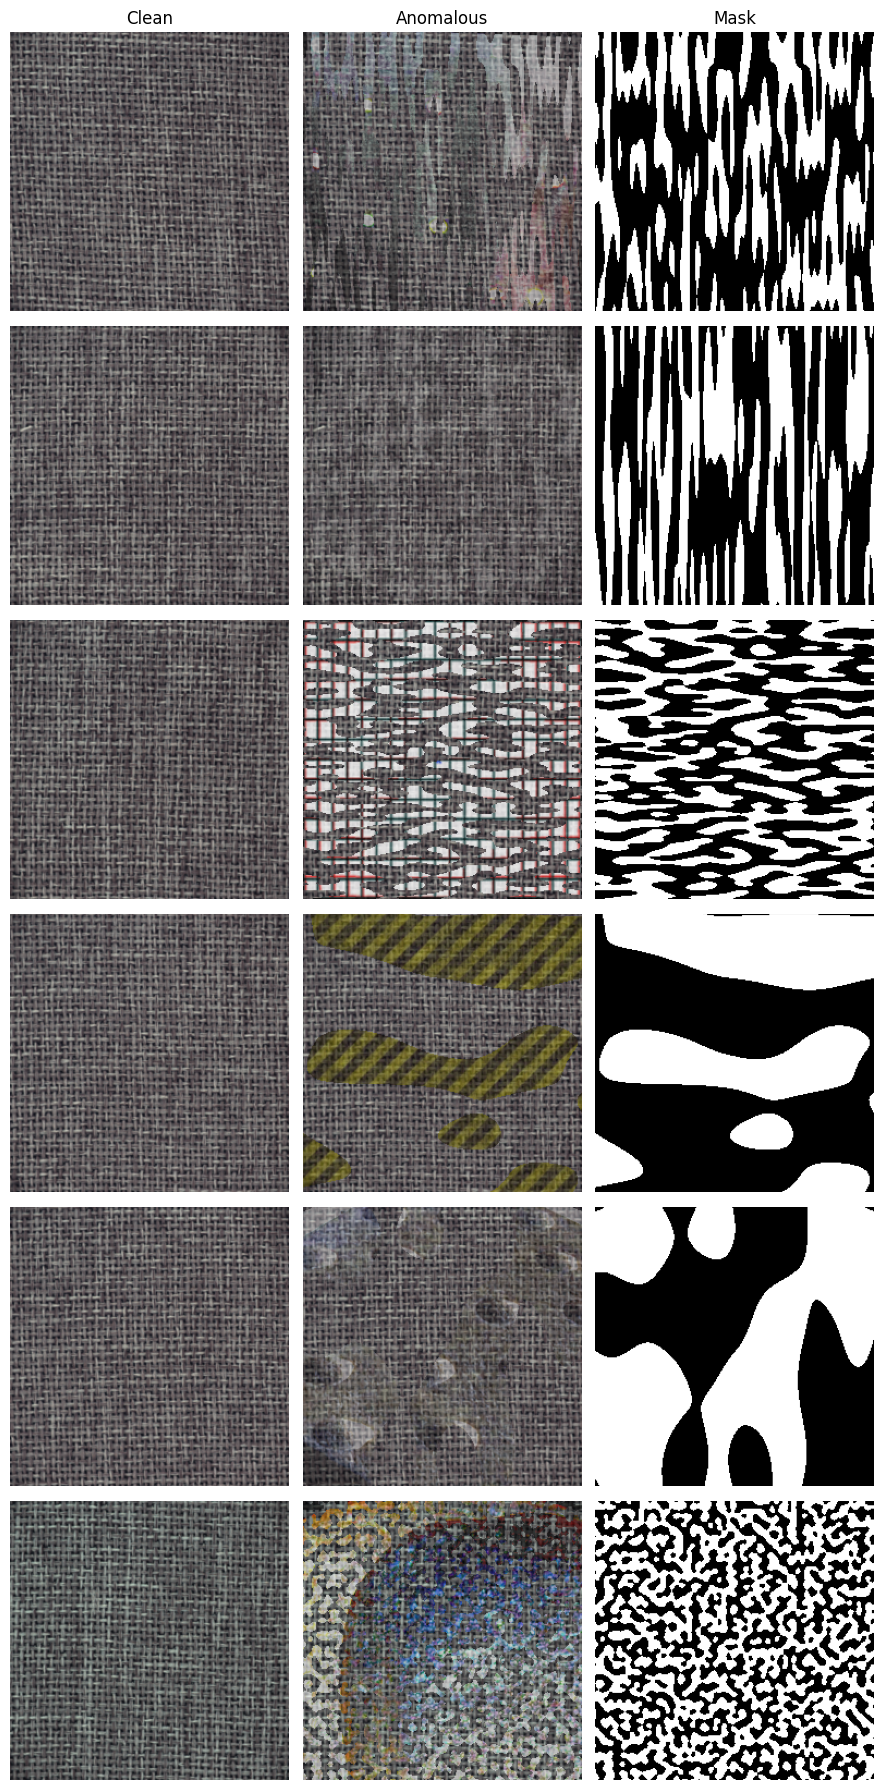

In [15]:
# ============================================================
# Cell 6: Visualise pixel‑space synthetic anomalies (clean vs. anomalous + mask)
# ============================================================
def visualize_pixel_anomaly_generator(gen, clean_dataset, num_samples=6, device='cuda'):
    """
    Display clean, anomalous, and anomaly mask for synthetic anomalies
    created by the DiffADAnomalyGenerator.

    Args:
        gen:           DiffADAnomalyGenerator instance
        clean_dataset: SingleCategoryGoodDataset (or any Dataset returning clean images)
        num_samples:   number of rows to show
        device:        torch device (the generator already runs on the correct device)
    """
    # Collect clean images
    indices = torch.randint(0, len(clean_dataset), (num_samples,))
    clean_imgs = [clean_dataset[i] for i in indices]   # each (3, 256, 256) in [-1,1]

    anom_imgs, masks = [], []
    for img in clean_imgs:
        anom, mask = gen.generate_pair(img)
        anom_imgs.append(anom)
        masks.append(mask)

    # Normalise to [0,1] for display
    def to_show(tensor):
        tensor = tensor.permute(1, 2, 0) if tensor.dim() == 3 else tensor
        tensor = (tensor + 1) / 2.0
        return tensor.clamp(0, 1)

    fig, axes = plt.subplots(num_samples, 3, figsize=(9, 3 * num_samples))
    if num_samples == 1:
        axes = axes[None, :]

    for i in range(num_samples):
        axes[i, 0].imshow(to_show(clean_imgs[i]))
        axes[i, 0].set_title("Clean" if i == 0 else "")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(to_show(anom_imgs[i]))
        axes[i, 1].set_title("Anomalous" if i == 0 else "")
        axes[i, 1].axis('off')

        mask_show = masks[i].squeeze(0)   # (H, W) in {0,1}
        axes[i, 2].imshow(mask_show, cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title("Mask" if i == 0 else "")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


# ---- Example usage ----
visualize_pixel_anomaly_generator(
    gen=anomaly_gen_pixel,          # already instantiated in Cell 4b
    clean_dataset=good_dataset,     # from Cell 3a
    num_samples=6,
    device=device
)

In [16]:
# # ============================================================
# # Early diagnostic cell (place after VAE & carpet dataset are loaded)
# # Tests:  (A) Anomaly‑map formula (best‑case)
# #         (B) VAE background distortion
# # ============================================================
# import torch.nn.functional as F
# import numpy as np
# import random, math
# from PIL import Image
# import imgaug.augmenters as iaa

# # ========== 1. Ensure DTD dataset is loaded ==========
# if 'anomaly_dataset' not in dir():
#     dtd_transform = transforms.Compose([
#         transforms.Resize((256, 256)),
#         transforms.ToTensor(),
#         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
#     ])
#     anomaly_dataset = datasets.DTD(root="./dtd_data", split='train', download=False, transform=dtd_transform)
#     print(f"DTD anomaly source reloaded: {len(anomaly_dataset)} images.")

# # ========== 2. Perlin helpers (self‑contained) ==========
# def _fade(t): return 6 * t**5 - 15 * t**4 + 10 * t**3

# def generate_perlin_noise_2d_np(shape, res):
#     H, W = shape
#     rx, ry = int(max(1, res[0])), int(max(1, res[1]))
#     grid_x = rx + 1; grid_y = ry + 1
#     angles = 2.0 * np.pi * np.random.rand(grid_y, grid_x)
#     grads = np.stack((np.cos(angles), np.sin(angles)), axis=-1)
#     xs = np.linspace(0, rx, W, endpoint=False)
#     ys = np.linspace(0, ry, H, endpoint=False)
#     X, Y = np.meshgrid(xs, ys)
#     x0 = np.floor(X).astype(int); y0 = np.floor(Y).astype(int)
#     xf = X - x0; yf = Y - y0
#     x1 = x0 + 1; y1 = y0 + 1
#     x0c = np.clip(x0, 0, rx); x1c = np.clip(x1, 0, rx)
#     y0c = np.clip(y0, 0, ry); y1c = np.clip(y1, 0, ry)
#     g00 = grads[y0c, x0c]; g10 = grads[y0c, x1c]
#     g01 = grads[y1c, x0c]; g11 = grads[y1c, x1c]
#     d00 = np.stack([xf, yf], axis=-1)
#     d10 = np.stack([xf-1, yf], axis=-1)
#     d01 = np.stack([xf, yf-1], axis=-1)
#     d11 = np.stack([xf-1, yf-1], axis=-1)
#     n00 = np.sum(g00*d00, axis=-1); n10 = np.sum(g10*d10, axis=-1)
#     n01 = np.sum(g01*d01, axis=-1); n11 = np.sum(g11*d11, axis=-1)
#     fx = _fade(xf); fy = _fade(yf)
#     nx0 = n00*(1-fx) + n10*fx; nx1 = n01*(1-fx) + n11*fx
#     n = nx0*(1-fy) + nx1*fy
#     return n.astype(np.float32)

# def generate_fractal_noise_2d_np(shape, res, octaves=1, persistence=0.5):
#     H, W = shape
#     noise = np.zeros((H,W), dtype=np.float32)
#     freq = 1.0; amp = 1.0
#     for _ in range(max(1,int(octaves))):
#         rx = max(1, int(round(res[0]*freq)))
#         ry = max(1, int(round(res[1]*freq)))
#         noise += amp * generate_perlin_noise_2d_np((H,W), (rx,ry))
#         freq *= 2.0; amp *= persistence
#     mn, mx = noise.min(), noise.max()
#     if mx - mn > 1e-9: noise = (noise - mn) / (mx - mn)
#     else: noise = np.zeros_like(noise, dtype=np.float32)
#     return noise

# # ========== 3. Maximum Dice calculator (same as in later cells) ==========
# def compute_max_dice(anomaly_map, gt_mask, num_thresh=100):
#     flat_map = anomaly_map.flatten()
#     flat_gt = gt_mask.flatten()
#     if flat_map.max() == 0: return 0.0
#     thresholds = np.logspace(-3, np.log10(flat_map.max() + 1e-8), num_thresh)
#     best = 0.0
#     for th in thresholds:
#         pred = (flat_map > th).astype(np.float32)
#         intersection = (pred * flat_gt).sum()
#         dice = 2 * intersection / (pred.sum() + flat_gt.sum() + 1e-8)
#         if dice > best: best = dice
#     return best

# # ========== 4. Helper: create pixel‑space anomaly with known mask ==========
# def create_pixel_anomaly_with_mask(clean_image, anomaly_texture, 
#                                    max_anomaly_area=0.10, beta_range=(0.1,0.9),
#                                    perlin_exp_range=(1,5), octaves=1, persistence=0.5,
#                                    gaussian_std=0.05, perlin_scale=0.3,
#                                    gauss_sigma_frac=(0.08,0.30), gauss_angle_range=(-45,45),
#                                    device='cuda'):
#     H, W = 256, 256
#     I = clean_image.to(device)
#     A = anomaly_texture.to(device)
#     aug = iaa.Sequential([
#         iaa.Sometimes(0.7, iaa.LinearContrast((0.8,1.2))),
#         iaa.Sometimes(0.7, iaa.Multiply((0.9,1.1))),
#         iaa.Sometimes(0.5, iaa.Affine(rotate=(-20,20), scale=(0.9,1.1), shear=(-5,5), mode='reflect')),
#         iaa.Sometimes(0.4, iaa.Fliplr(0.5)), iaa.Sometimes(0.2, iaa.Flipud(0.5)),
#         iaa.Sometimes(0.5, iaa.AddToHueAndSaturation((-20,20))),
#         iaa.Sometimes(0.5, iaa.Add((-10,10)))
#     ], random_order=True)
#     A_np = A.permute(1,2,0).cpu().numpy()
#     A_np = (A_np+1)/2*255; A_np = A_np.clip(0,255).astype(np.uint8)
#     A_aug_uint8 = aug(image=A_np)
#     A_aug = A_aug_uint8.astype(np.float32)/255*2 - 1
#     A_aug_t = torch.from_numpy(A_aug).to(device)

#     exp_x = random.randint(*perlin_exp_range); exp_y = random.randint(*perlin_exp_range)
#     base_res = (2**exp_x, 2**exp_y)
#     perlin_np = generate_fractal_noise_2d_np((H,W), base_res, octaves, persistence)
#     perlin_t = torch.from_numpy(perlin_np).float().to(device).unsqueeze(-1)

#     cx = random.uniform(0.25*W,0.75*W); cy = random.uniform(0.25*H,0.75*H)
#     sx = random.uniform(*gauss_sigma_frac)*W; sy = random.uniform(*gauss_sigma_frac)*H
#     angle = random.uniform(*gauss_angle_range)
#     def _elliptic_gaussian(H,W,cx,cy,sx,sy,angle_deg):
#         ys = torch.arange(0,H,device=device).float(); xs = torch.arange(0,W,device=device).float()
#         Y,X = torch.meshgrid(ys,xs,indexing='ij')
#         Xc = X-float(cx); Yc = Y-float(cy)
#         theta = math.radians(angle_deg)
#         c,s = math.cos(theta),math.sin(theta)
#         Xr =  c*Xc + s*Yc; Yr = -s*Xc + c*Yc
#         gx = (Xr**2)/(2*sx**2+1e-9); gy = (Yr**2)/(2*sy**2+1e-9)
#         g = torch.exp(-(gx+gy)); g = g/(g.max()+1e-9)
#         return g.unsqueeze(-1)
#     gauss = _elliptic_gaussian(H,W,cx,cy,sx,sy,angle)
#     perlin_local = perlin_t * gauss
#     perlin_local *= (0.7 + 0.6*random.random())

#     flat = perlin_local.flatten()
#     cutoff = max(1,int(max_anomaly_area*H*W))
#     thr = torch.sort(flat)[0][-cutoff].item()
#     M = (perlin_local > thr).float()          # binary mask
#     M_rgb = M.repeat(1,1,3)

#     noise = gaussian_std * torch.randn_like(A_aug_t, device=device)
#     A_noisy = A_aug_t + perlin_scale*perlin_local.repeat(1,1,3) + noise
#     A_noisy = torch.clamp(A_noisy, -1,1)

#     beta = random.uniform(*beta_range)
#     I_hw3 = I.permute(1,2,0)
#     I_a_hw3 = I_hw3*(1-M_rgb) + (1-beta)*(M_rgb*A_noisy) + beta*(M_rgb*I_hw3)
#     I_a = I_a_hw3.permute(2,0,1)
#     return I_a.cpu(), M.permute(2,0,1).cpu()   # anomalous image, binary mask

# # ========================================================================
# # TEST A – isolate the anomaly‑map formula (perfect model simulation)
# # ========================================================================
# def test_anomaly_map_formula(vae, scale_factor, clean_img, anomaly_texture, device='cuda'):
#     """
#     Simulate a perfect flow model: the reconstructed image is the clean image,
#     the reconstructed latent is the clean latent.
#     Compute the exact anomaly_map_conditional using that perfect reconstruction.
#     """
#     # Create synthetic anomaly using the clean image (so we know the true mask)
#     anom_img, true_mask = create_pixel_anomaly_with_mask(clean_img, anomaly_texture, device=device)
#     true_mask = (true_mask > 0).float()   # ensure binary

#     # Encode the clean image (simulates perfect reconstruction latent)
#     with torch.no_grad():
#         clean_latent = vae.encode(clean_img.unsqueeze(0).to(device)).latent_dist.mode() * scale_factor
#         # For the composite image, encode it as well (to get "anomalous latent")
#         anom_latent = vae.encode(anom_img.unsqueeze(0).to(device)).latent_dist.mode() * scale_factor

#     # Simulate the anomaly map as if the model returned clean_latent
#     # We follow the formula exactly:
#     #   diff_img = |decode(clean_latent) - anom_img|
#     #   diff_lat = |clean_latent - anom_latent|  (resized)
#     with torch.no_grad():
#         recon_img = vae.decode(clean_latent / scale_factor).sample   # (1,3,256,256)
#         diff_img = (recon_img - anom_img.unsqueeze(0).to(device)).abs().mean(dim=1, keepdim=True)  # (1,1,H,W)
#         diff_lat = (clean_latent - anom_latent).abs().mean(dim=1, keepdim=True)                    # (1,1,32,32)
#         diff_lat_resized = F.interpolate(diff_lat, size=anom_img.shape[-2:],
#                                          mode='bilinear', align_corners=False)                     # (1,1,H,W)
#         amap = (0.5 * diff_img + 0.5 * diff_lat_resized).squeeze().cpu().numpy()
#     gt = true_mask.squeeze().numpy()
#     dice = compute_max_dice(amap, gt, num_thresh=100)
#     return dice, anom_img, recon_img.squeeze(0).cpu(), true_mask.squeeze(0), amap

# # ========================================================================
# # TEST B – isolate VAE background error (simple image difference)
# # ========================================================================
# def test_vae_reconstruction_error(vae, scale_factor, clean_img, anomaly_texture, device='cuda'):
#     """
#     Measures how much the VAE's encode‑decode cycle distorts a composite
#     (clean + synthetic anomaly) relative to the ORIGINAL clean image.
    
#     Returns Dice of the simple image‑space difference |VAE_recon − original|.
#     """
#     # 1) Create a synthetic anomaly ON THE ORIGINAL clean image
#     anom_img, true_mask = create_pixel_anomaly_with_mask(clean_img, anomaly_texture, device=device)
#     true_mask = (true_mask > 0).float()
    
#     # 2) Pass the anomalous composite through the VAE
#     with torch.no_grad():
#         anom_latent = vae.encode(anom_img.unsqueeze(0).to(device)).latent_dist.mode() * scale_factor
#         vae_recon = vae.decode(anom_latent / scale_factor).sample.squeeze(0)  # VAE‑reconstructed composite
#     # 3) Compute difference map against ORIGINAL clean image
#     diff = (vae_recon.cpu() - clean_img).abs().mean(dim=0, keepdim=True)  # (1,H,W)
#     amap = diff.squeeze().numpy()
#     gt = true_mask.squeeze().numpy()
#     dice = compute_max_dice(amap, gt, num_thresh=100)
#     return dice, anom_img.cpu(), vae_recon.cpu(), true_mask.squeeze(0), amap

# # ========== 5. Run both tests ==========
# num_test = 20
# dice_A = []
# dice_B = []
# print("Running diagnostics on carpet images ...")
# for i in range(num_test):
#     clean_img = good_dataset[i]
#     tex_idx = random.randint(0, len(anomaly_dataset)-1)
#     tex_img, _ = anomaly_dataset[tex_idx]

#     dA, anom_A, recon_A, mask_A, amap_A = test_anomaly_map_formula(vae, scale_factor, clean_img, tex_img, device=device)
#     dB, anom_B, recon_B, mask_B, amap_B = test_vae_background_error(vae, scale_factor, clean_img, tex_img, device=device)
#     dice_A.append(dA)
#     dice_B.append(dB)

# print(f"\nTest A – Anomaly‑map formula (perfect model): avg Dice = {np.mean(dice_A):.4f}")
# print("  Individual:", [f"{d:.3f}" for d in dice_A])
# print(f"Test B – VAE background error (image diff only): avg Dice = {np.mean(dice_B):.4f}")
# print("  Individual:", [f"{d:.3f}" for d in dice_B])

# # Sanity: Dice of mask against itself
# self_dice = compute_max_dice(mask_A.numpy(), mask_A.numpy(), num_thresh=100)
# print(f"\nDice of GT mask vs itself: {self_dice:.4f} (should be 1.0)")

# # Visualise first sample of each test
# fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# axes[0,0].imshow((recon_A.permute(1,2,0)+1)/2)
# axes[0,0].set_title("Test A: Perfect recon")
# axes[0,1].imshow((anom_A.permute(1,2,0)+1)/2)
# axes[0,1].set_title("Anomalous image")
# axes[0,2].imshow(mask_A, cmap='gray')
# axes[0,2].set_title("GT mask")
# axes[0,3].imshow(amap_A, cmap='hot')
# axes[0,3].set_title(f"Anomaly map (Dice={dice_A[0]:.3f})")

# axes[1,0].imshow((recon_B.permute(1,2,0)+1)/2)
# axes[1,0].set_title("Test B: VAE recon")
# axes[1,1].imshow((anom_B.permute(1,2,0)+1)/2)
# axes[1,1].set_title("Anomalous on VAE recon")
# axes[1,2].imshow(mask_B, cmap='gray')
# axes[1,2].set_title("GT mask")
# axes[1,3].imshow(amap_B, cmap='hot')
# axes[1,3].set_title(f"Image diff (Dice={dice_B[0]:.3f})")
# for ax in axes.flat: ax.axis('off')
# plt.tight_layout()
# plt.show()

# Part B – Probability Path, Rectified Flow Model, and Trainer

Probability Path Classes

In [17]:
# ============================================================
# Cell 7a: Conditional Probability Path
# ============================================================
class ConditionalLatentPath:
    """
    Linear interpolation between noise (z0) and clean latent (z1).
    Conditioning is passed through to the model but not used in the path itself.
    """
    def __init__(self, sampler, device):
        self.sampler = sampler
        self.device = device

    def sample_conditioning_variable(self, num_samples):
        z0, z1, cond = self.sampler.sample_training_batch(num_samples)
        return (z0.to(self.device), z1.to(self.device), cond.to(self.device))

    def sample_conditional_path(self, z, t):
        z0, z1 = z    # z = (z0, z1) – no need for conditioning in interpolation
        return (1 - t) * z0 + t * z1

    def conditional_vector_field(self, x, z, t):
        # not used directly; we compute v_ref manually in trainer
        pass

In [18]:
# # ============================================================
# # Cell 7b: Visualize noise → clean latent linear path
# # ============================================================
# def visualize_noise_to_clean_path(
#     sampler: FastGPUSampler,
#     vae: nn.Module,
#     scale_factor: float,
#     num_samples: int = 6,
#     num_steps: int = 5,
#     device: torch.device = None
# ):
#     """
#     Visualize linear interpolation between pure noise (t=0) and
#     clean latents (t=1), decoding each step to pixel space.

#     Each row shows the trajectory for one sample: from pure noise
#     to the clean carpet image. The conditioning latent is ignored
#     here because we only inspect the unconditional path geometry.
#     """
#     if device is None:
#         device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#     # ---- 1) Get noise and clean latents ----
#     z0, z_clean, _ = sampler.sample_training_batch(num_samples)
#     z0 = z0.to(device)
#     z_clean = z_clean.to(device)

#     # ---- 2) Interpolate and decode ----
#     t_vals = torch.linspace(0, 1, num_steps, device=device)
#     decoded = []

#     with torch.no_grad():
#         for t in t_vals:
#             t_expanded = t.view(1, 1, 1, 1)
#             z_t = (1 - t_expanded) * z0 + t_expanded * z_clean
#             pixels = vae.decode(z_t / scale_factor).sample
#             decoded.append(pixels.cpu())

#     # ---- 3) Plot ----
#     fig, axes = plt.subplots(num_samples, num_steps,
#                              figsize=(2.5 * num_steps, 2.5 * num_samples))
#     if num_samples == 1:
#         axes = axes[None, :]

#     for i in range(num_samples):
#         for s, img_batch in enumerate(decoded):
#             ax = axes[i, s]
#             img = img_batch[i]                          # (3, H, W)
#             img = img.permute(1, 2, 0)                  # -> (H, W, 3)
#             img = (img + 1.0) / 2.0                     # [-1,1] -> [0,1]
#             img = img.clamp(0, 1)
#             ax.imshow(img)
#             ax.axis('off')
#             if i == 0:
#                 ax.set_title(f"t={t_vals[s]:.2f}")

#     plt.tight_layout()
#     plt.show()


# # ---- Example usage ----
# visualize_noise_to_clean_path(
#     sampler=gpu_sampler,      # ← FastGPUSampler instance
#     vae=vae,
#     scale_factor=scale_factor,
#     num_samples=6,
#     num_steps=6,
#     device=device
# )

U‑Net Model (velocity network)

In [19]:
# ============================================================
# Cell 8: U‑Net helpers and Model (velocity network)
# ============================================================
# Stability design principles (see analysis):
#  1. Attention: QK‑Norm + FP32 softmax + logit clamp → prevents Inf/NaN
#  2. ResNet FiLM: clamp modulation parameters → prevents activation overflow
#  3. Skip connections: optional scaling (ScaleLong) → reduces gradient oscillation
#  4. Normalization: GroupNorm (conv) + LayerNorm (attention) → stable statistics
# ============================================================

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

MiB = 1024 ** 2

# ----------------------------------------------------------------------
# Helper functions
# ----------------------------------------------------------------------
def model_size_b(model: nn.Module) -> int:
    """Return model size in bytes."""
    size = 0
    for param in model.parameters():
        size += param.nelement() * param.element_size()
    for buf in model.buffers():
        size += buf.nelement() * buf.element_size()
    return size

def get_timestep_embedding(timesteps: torch.Tensor, embedding_dim: int) -> torch.Tensor:
    """
    Sinusoidal timestep embedding (same as DDPM).
    Args:
        timesteps: 1D LongTensor of shape (B,)
        embedding_dim: output dimension
    Returns:
        emb: (B, embedding_dim) float tensor
    """
    assert timesteps.dim() == 1, "timesteps should be 1D (shape [B])"
    half_dim = embedding_dim // 2
    # log(10000) scaled frequencies
    emb = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, dtype=torch.float32, device=timesteps.device) * -emb)
    emb = timesteps.float()[:, None] * emb[None, :]
    # interleave sin and cos
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if embedding_dim % 2 == 1:
        emb = F.pad(emb, (0, 1, 0, 0))
    return emb

def nonlinearity(x: torch.Tensor) -> torch.Tensor:
    """Swish activation: x * sigmoid(x)."""
    return x * torch.sigmoid(x)

def Normalize(in_channels: int, num_groups: int = 32):
    """
    GroupNorm with number of groups capped by in_channels.
    Standard for U‑Nets: avoids batch‑size dependence.
    """
    ng = min(num_groups, in_channels)
    return nn.GroupNorm(num_groups=ng, num_channels=in_channels, eps=1e-6, affine=True)

# ----------------------------------------------------------------------
# Up/Downsampling (unchanged)
# ----------------------------------------------------------------------
class Upsample(nn.Module):
    """Nearest‑neighbour upsampling, optionally followed by a 3×3 conv."""
    def __init__(self, in_channels: int, with_conv: bool):
        super().__init__()
        self.with_conv = with_conv
        if with_conv:
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1)
    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="nearest")
        if self.with_conv:
            x = self.conv(x)
        return x

class Downsample(nn.Module):
    """Strided convolution (or average pooling) for 2× downsampling."""
    def __init__(self, in_channels: int, with_conv: bool):
        super().__init__()
        self.with_conv = with_conv
        if with_conv:
            # pad right/bottom to emulate 'same' before stride‑2 conv
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=2, padding=0)
    def forward(self, x):
        if self.with_conv:
            pad = (0, 1, 0, 1)          # (left, right, top, bottom)
            x = F.pad(x, pad, mode="constant", value=0)
            x = self.conv(x)
        else:
            x = F.avg_pool2d(x, kernel_size=2, stride=2)
        return x

# ----------------------------------------------------------------------
# ResNet block (stabilised FiLM injection)
# ----------------------------------------------------------------------
class ResnetBlock(nn.Module):
    """
    Residual block with GroupNorm, Swish, and optional time embedding.
    Supports FiLM (scale+shift) modulation, with clamped modulation parameters
    to prevent FP16 overflow (stability fix #2).
    """
    def __init__(self, *, in_channels, out_channels=None, conv_shortcut=False,
                 dropout=0.0, temb_channels=512, use_film=False):
        super().__init__()
        self.in_channels = in_channels
        out_channels = in_channels if out_channels is None else out_channels
        self.out_channels = out_channels
        self.use_conv_shortcut = conv_shortcut
        self.use_film = use_film

        self.norm1 = Normalize(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)

        if temb_channels and temb_channels > 0:
            if use_film:
                self.temb_proj = nn.Linear(temb_channels, 2 * out_channels)  # scale & shift
            else:
                self.temb_proj = nn.Linear(temb_channels, out_channels)      # additive bias
        else:
            self.temb_proj = None

        self.norm2 = Normalize(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)

        # shortcut if channels differ
        if self.in_channels != self.out_channels:
            if self.use_conv_shortcut:
                self.conv_shortcut = nn.Conv2d(in_channels, out_channels,
                                               kernel_size=3, stride=1, padding=1)
            else:
                self.nin_shortcut = nn.Conv2d(in_channels, out_channels,
                                              kernel_size=1, stride=1, padding=0)

    def forward(self, x, temb=None):
        h = x
        h = self.norm1(h)
        h = nonlinearity(h)
        h = self.conv1(h)

        if temb is not None and self.temb_proj is not None:
            temb_out = self.temb_proj(nonlinearity(temb)).float()  # cast to fp32 for safety

            if self.use_film:
                scale, shift = torch.chunk(temb_out, 2, dim=1)
                # Clamp to prevent extreme modulation → FP16 overflow (stability fix #2)
                scale = torch.clamp(scale, min=-10.0, max=10.0)
                shift = torch.clamp(shift, min=-10.0, max=10.0)
                # Apply FiLM in float32, then later converted back
                h = h.float() * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
            else:
                h = h.float() + temb_out[:, :, None, None]

        h = self.norm2(h)
        h = nonlinearity(h)
        h = self.dropout(h)
        h = self.conv2(h)

        if self.in_channels != self.out_channels:
            if self.use_conv_shortcut:
                x = self.conv_shortcut(x)
            else:
                x = self.nin_shortcut(x)

        return x + h.to(x.dtype)


class AttnBlock(nn.Module):
    """
    Multi‑head self‑attention using F.scaled_dot_product_attention.
    """
    def __init__(self, in_channels, num_heads=4):
        super().__init__()
        assert in_channels % num_heads == 0, \
            f"in_channels={in_channels} must be divisible by num_heads={num_heads}"
        self.in_channels = in_channels
        self.num_heads = num_heads
        self.head_dim = in_channels // num_heads

        self.norm = Normalize(in_channels)
        self.qkv = nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1)
        self.proj_out = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def forward(self, x):
        b, c, h, w = x.shape
        L = h * w

        h_ = self.norm(x)
        qkv = self.qkv(h_)                          # (B, 3C, H, W)
        qkv = qkv.reshape(b, 3, self.num_heads,
                          self.head_dim, L)          # (B, 3, heads, head_dim, L)
        qkv = qkv.permute(1, 0, 2, 4, 3)            # (3, B, heads, L, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]            # each (B, heads, L, head_dim)

        # F.scaled_dot_product_attention handles (B, heads, L, dim) natively
        out = F.scaled_dot_product_attention(q, k, v)  # (B, heads, L, head_dim)

        out = out.permute(0, 2, 1, 3)                # (B, L, heads, head_dim)
        out = out.reshape(b, c, h, w)                # (B, C, H, W)
        out = self.proj_out(out)
        return x + out

# ----------------------------------------------------------------------
# U‑Net Model (with optional skip‑connection scaling)
# ----------------------------------------------------------------------
class Model(nn.Module):
    """
    Conditional U‑Net following the DiffAD / Zhang‑style design.

    Parameters
    ----------
    ch : int
        Base number of channels.
    out_ch : int
        Output channels (velocity field).
    ch_mult : tuple of int
        Channel multiplier for each resolution level.
    num_res_blocks : int or tuple of int
        Number of ResNet blocks per level.  If an integer, the same number
        of blocks is used at every resolution.  If a tuple / list, it must
        have one entry per resolution (e.g. ``(2, 2, 3)`` gives 3 blocks
        at the bottleneck and 2 blocks elsewhere).
    attn_resolutions : tuple of int
        Spatial sizes at which to apply self‑attention in the **encoder**.
    decoder_attn_resolutions : tuple of int, optional
        Spatial sizes for attention in the **decoder**.  When ``None``
        (default), the decoder uses the same resolutions as the encoder.
    dropout : float
        Dropout rate in ResNet blocks.
    resamp_with_conv : bool
        Whether to use a convolution for up‑ / down‑sampling.
    in_channels : int
        Number of input channels (noise + conditioning concatenated).
    resolution : int
        Spatial size of the input latent.
    use_timestep : bool
        Whether to create a timestep embedding.
    use_film : bool
        If True, inject timestep information via FiLM (scale+shift);
        otherwise use simple addition.
    num_heads : int
        Number of attention heads.
    skip_scale : float
        Scale factor for skip connections (ScaleLong; 1.0 = off).
    """

    def __init__(
        self,
        *,
        ch: int,
        out_ch: int,
        ch_mult=(1, 2, 4, 8),
        num_res_blocks: int = 2,
        attn_resolutions=(),
        decoder_attn_resolutions=None,       # NEW: separate decoder attention
        dropout: float = 0.0,
        resamp_with_conv: bool = True,
        in_channels: int = 8,
        resolution: int = 32,
        use_timestep: bool = True,
        use_film: bool = True,
        num_heads: int = 4,
        skip_scale: float = 0.7,
    ):
        super().__init__()
        self.ch = ch
        self.temb_ch = ch * 4
        self.num_resolutions = len(ch_mult)
        self.num_res_blocks = num_res_blocks       # store raw input (int or tuple)
        self.resolution = resolution
        self.in_channels = in_channels
        self.use_timestep = use_timestep
        self.skip_scale = skip_scale

        # ---- attention resolution sets ----------------------------------
        self.encoder_attn_res = set(attn_resolutions)
        if decoder_attn_resolutions is not None:
            self.decoder_attn_res = set(decoder_attn_resolutions)
        else:
            self.decoder_attn_res = set(attn_resolutions)

        # ---- timestep embedding (sinusoidal → 2‑layer MLP) --------------
        if use_timestep:
            self.temb = nn.Module()
            self.temb.dense = nn.ModuleList([
                nn.Linear(self.ch, self.temb_ch),
                nn.Linear(self.temb_ch, self.temb_ch),
            ])

        # ---- input convolution ------------------------------------------
        self.conv_in = nn.Conv2d(in_channels, self.ch, kernel_size=3,
                                 stride=1, padding=1)

        # ---- encoder ----------------------------------------------------
        curr_res = resolution
        in_ch_mult = (1,) + tuple(ch_mult)
        self.down = nn.ModuleList()
        block_in = self.ch

        for i_level in range(self.num_resolutions):
            block = nn.ModuleList()
            attn = nn.ModuleList()
            block_out = self.ch * ch_mult[i_level]

            # Number of ResNet blocks for this resolution
            level_blocks = (self.num_res_blocks[i_level]
                            if isinstance(self.num_res_blocks, (list, tuple))
                            else self.num_res_blocks)

            for _ in range(level_blocks):
                block.append(
                    ResnetBlock(
                        in_channels=block_in,
                        out_channels=block_out,
                        temb_channels=self.temb_ch,
                        dropout=dropout,
                        use_film=use_film,
                    )
                )
                block_in = block_out
                # Attention at this resolution?
                if curr_res in self.encoder_attn_res:
                    attn.append(AttnBlock(block_in, num_heads=num_heads))

            down = nn.Module()
            down.block = block
            down.attn = attn
            if i_level != self.num_resolutions - 1:
                down.downsample = Downsample(block_in, with_conv=resamp_with_conv)
                curr_res = curr_res // 2
            self.down.append(down)

        # ---- bottleneck -------------------------------------------------
        self.mid = nn.Module()
        self.mid.block_1 = ResnetBlock(
            in_channels=block_in, out_channels=block_in,
            temb_channels=self.temb_ch, dropout=dropout, use_film=use_film,
        )
        self.mid.attn_1 = AttnBlock(block_in, num_heads=num_heads)
        self.mid.block_2 = ResnetBlock(
            in_channels=block_in, out_channels=block_in,
            temb_channels=self.temb_ch, dropout=dropout, use_film=use_film,
        )

        # ---- decoder ----------------------------------------------------
        self.up = nn.ModuleList()
        for i_level in reversed(range(self.num_resolutions)):
            block = nn.ModuleList()
            attn = nn.ModuleList()
            block_out = self.ch * ch_mult[i_level]
            skip_in = self.ch * ch_mult[i_level]

            level_blocks = (self.num_res_blocks[i_level]
                            if isinstance(self.num_res_blocks, (list, tuple))
                            else self.num_res_blocks)

            for i_block in range(level_blocks + 1):   # +1 for the skip‑connection block
                if i_block == level_blocks:
                    skip_in = self.ch * in_ch_mult[i_level]
                block.append(
                    ResnetBlock(
                        in_channels=block_in + skip_in,
                        out_channels=block_out,
                        temb_channels=self.temb_ch,
                        dropout=dropout,
                        use_film=use_film,
                    )
                )
                block_in = block_out
                if curr_res in self.decoder_attn_res:
                    attn.append(AttnBlock(block_in, num_heads=num_heads))

            up = nn.Module()
            up.block = block
            up.attn = attn
            if i_level != 0:
                up.upsample = Upsample(block_in, resamp_with_conv)
                curr_res = curr_res * 2
            self.up.insert(0, up)

        # ---- output -----------------------------------------------------
        self.norm_out = Normalize(block_in)
        self.conv_out = nn.Conv2d(block_in, out_ch, kernel_size=3,
                                  stride=1, padding=1)

    # -----------------------------------------------------------------
    # forward pass (unchanged, but uses per‑level block counts now)
    # -----------------------------------------------------------------
    def forward(self, x, t=None, context=None):
        B = x.shape[0]

        # timestep embedding
        if self.use_timestep:
            if t is None:
                raise AssertionError("timestep required but not provided")
            if t.ndim == 1:
                t_flat = t
            elif t.ndim == 4 and t.shape[0] == B and tuple(t.shape[1:]) == (1, 1, 1):
                t_flat = t.view(B)
            else:
                raise ValueError(f"Unexpected timestep shape {tuple(t.shape)}")
            temb = get_timestep_embedding(t_flat, self.ch)
            temb = self.temb.dense[0](temb)
            temb = nonlinearity(temb)
            temb = self.temb.dense[1](temb)
        else:
            temb = None

        if context is not None:
            x = torch.cat((x, context), dim=1)

        # encoder
        hs = [self.conv_in(x)]
        for i_level in range(self.num_resolutions):
            # Per‑level block count (same logic as __init__)
            level_blocks = (self.num_res_blocks[i_level]
                            if isinstance(self.num_res_blocks, (list, tuple))
                            else self.num_res_blocks)
            for i_block in range(level_blocks):
                h = self.down[i_level].block[i_block](hs[-1], temb)
                if len(self.down[i_level].attn) > 0:
                    h = self.down[i_level].attn[i_block](h)
                hs.append(h)
            if i_level != self.num_resolutions - 1:
                hs.append(self.down[i_level].downsample(hs[-1]))

        # bottleneck
        h = hs[-1]
        h = self.mid.block_1(h, temb)
        h = self.mid.attn_1(h)
        h = self.mid.block_2(h, temb)

        # decoder
        for i_level in reversed(range(self.num_resolutions)):
            level_blocks = (self.num_res_blocks[i_level]
                            if isinstance(self.num_res_blocks, (list, tuple))
                            else self.num_res_blocks)
            for i_block in range(level_blocks + 1):
                skip = hs.pop()
                if self.skip_scale != 1.0:
                    skip = skip * self.skip_scale
                h = self.up[i_level].block[i_block](
                    torch.cat([h, skip], dim=1), temb
                )
                if len(self.up[i_level].attn) > 0:
                    h = self.up[i_level].attn[i_block](h)
            if i_level != 0:
                h = self.up[i_level].upsample(h)

        h = self.norm_out(h)
        h = nonlinearity(h)
        h = self.conv_out(h)
        return h


def zero_module(module):
    """Zero‑initialise the weights and bias of a module (DiffAD convention)."""
    nn.init.zeros_(module.weight)
    if module.bias is not None:
        nn.init.zeros_(module.bias)

In [20]:
# # Old Attention Block
# # ----------------------------------------------------------------------
# # Attention block (with QK‑Norm, FP32 softmax, logit clamp)
# # ----------------------------------------------------------------------
# class AttnBlock(nn.Module):
#     """
#     Multi‑head self‑attention with comprehensive stability measures (fix #1).
#     - QK‑Norm: LayerNorm on Q and K after projection constrains magnitude.
#     - FP32 softmax: prevents underflow/overflow in the exponential.
#     - Logit clamping: last‑resort safety net for extreme logits.
#     """
#     def __init__(self, in_channels, num_head_channels=32):
#         super().__init__()
#         self.in_channels = in_channels
#         self.num_head_channels = num_head_channels
#         self.num_heads = in_channels // num_head_channels

#         # Pre‑projection GroupNorm (standard in Diffusers)
#         self.norm = nn.GroupNorm(
#             num_groups=min(32, in_channels),
#             num_channels=in_channels,
#             eps=1e-6,
#             affine=True,
#         )

#         self.qkv = nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1)

#         # QK‑Norm: LayerNorm normalises each head's vector before dot product
#         self.q_norm = nn.LayerNorm(num_head_channels)
#         self.k_norm = nn.LayerNorm(num_head_channels)

#         self.proj_out = nn.Conv2d(in_channels, in_channels, kernel_size=1)

#     def forward(self, x):
#         b, c, h, w = x.shape
#         h_ = self.norm(x)

#         # 1) QKV projection and reshape into heads
#         qkv = self.qkv(h_).reshape(b, 3, self.num_heads, self.num_head_channels, h * w)
#         qkv = qkv.permute(1, 0, 2, 4, 3)          # (3, B, heads, N, head_dim)
#         q, k, v = qkv[0], qkv[1], qkv[2]

#         # 2) QK‑Norm: stabilise Q/K magnitudes before attention
#         q = self.q_norm(q)      # (B, heads, N, head_dim)
#         k = self.k_norm(k)

#         # 3) Scaled dot‑product attention (FP32 softmax + clamping)
#         scale = self.num_head_channels ** -0.5
#         q_f32 = q.float()
#         k_f32 = k.float()
#         attn_logits = (q_f32 @ k_f32.transpose(-2, -1)) * scale
#         # Safety clamp: logits beyond ±50 produce saturated one‑hot attention
#         attn_logits = torch.clamp(attn_logits, min=-50.0, max=50.0)
#         attn = torch.softmax(attn_logits, dim=-1).to(q.dtype)
#         out = attn @ v

#         # 4) Reshape and project back
#         out = out.transpose(1, 2).reshape(b, c, h, w)
#         out = self.proj_out(out)
#         return x + out


ODE and Simulator Classes

In [21]:
# ============================================================
# Cell 8b: build conditional UNet helper
# ============================================================
# Constructs a conditional UNet with all stability enhancements.
# Flags:
#   use_film                 – enables FiLM modulation (clamped for safety)
#   skip_scale               – coefficient for skip features (0.7 default → ScaleLong)
#   num_heads                – attention heads (4 heads → head_dim = in_channels/4)
#   num_res_blocks           – can be int (all levels) or tuple (per level)
#   decoder_attn_resolutions – if set, decoder uses different attention resolutions
# ============================================================

def build_conditional_unet(
    ch=64,                     # base channels
    out_ch=4,
    ch_mult=(1, 2, 4),        # narrower bottleneck (256 ch at 8×8)
    num_res_blocks=(2, 2, 3), # deeper only at bottleneck
    attn_resolutions=(8, 16), # encoder attention scales
    decoder_attn_resolutions=None,   # if None, mirrors encoder; else e.g. (8,)
    dropout=0.1,
    device=device,
    use_film=True,             # FiLM modulation (clamped for FP16 safety)
    num_heads=4,               # 4 heads, head_dim = in_channels/4
    skip_scale=0.7,            # ScaleLong scaling factor (1.0 = off)
):
    """
    Build a conditional U‑Net for latent Rectified Flow with an optimised
    balance of expressiveness and speed.

    Architecture highlights (defaults):
      - Base channels = 64, channel multipliers = (1,2,4) → bottleneck 256 ch.
      - Three ResNet blocks at the bottleneck, two at higher resolutions.
      - Multi‑head attention (4 heads) at 8×8 and 16×16 in the encoder;
        decoder attention can be set independently (default mirrors encoder).
      - FiLM conditioning for timestep injection, with clamped modulation
        parameters to prevent FP16 overflow.
      - ScaleLong skip‑connection scaling (0.7) for reduced gradient oscillation.
      - All attention output projections are zero‑initialised (DiffAD convention).

    Parameters
    ----------
    ch : int
        Base channel count (default 64).
    out_ch : int
        Output channels (velocity field), normally 4 for latent space.
    ch_mult : tuple of int
        Channel multiplier per resolution level (default (1,2,4)).
    num_res_blocks : int or tuple of int
        Number of ResNet blocks per level.  If a tuple, one value per resolution
        (e.g. (2,2,3) → 3 blocks at bottleneck).
    attn_resolutions : tuple of int
        Spatial sizes where attention is applied in the **encoder**.
    decoder_attn_resolutions : tuple of int, optional
        Spatial sizes for attention in the **decoder**.  When None, the decoder
        uses the same resolutions as the encoder.  Set to e.g. (8,) to drop
        decoder 16×16 attention.
    dropout : float
        Dropout rate inside ResNet blocks.
    device : torch.device
        Target device.
    use_film : bool
        If True, use FiLM (scale+shift) for timestep conditioning; else additive.
    num_heads : int
        Number of attention heads (default 4).
    skip_scale : float
        Multiplier for skip‑connection features (ScaleLong). 1.0 = disabled.

    Returns
    -------
    torch.nn.Module
        The conditional U‑Net on the specified device, with compiled
        stability enhancements.
    """
    unet = Model(
        ch=ch,
        out_ch=out_ch,
        ch_mult=ch_mult,
        num_res_blocks=num_res_blocks,           # int or tuple
        attn_resolutions=attn_resolutions,
        decoder_attn_resolutions=decoder_attn_resolutions,   # NEW
        dropout=dropout,
        resamp_with_conv=True,
        in_channels=8,            # 4 noise + 4 conditioning
        resolution=32,
        use_timestep=True,
        use_film=use_film,
        num_heads=num_heads,
        skip_scale=skip_scale,
    ).to(device)

    # Zero‑initialise attention output projections (follows DiffAD)
    zero_module(unet.mid.attn_1.proj_out)
    for down_level in unet.down:
        for attn in down_level.attn:
            if isinstance(attn, AttnBlock):
                zero_module(attn.proj_out)
    for up_level in unet.up:
        for attn in up_level.attn:
            if isinstance(attn, AttnBlock):
                zero_module(attn.proj_out)

    return unet

In [22]:
# ============================================================
# Cell 9: ODE, VectorField, Simulator (Euler, Heun)
# ============================================================
class ODE(ABC):
    """Abstract ODE interface."""
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        pass


class ConditionalVectorField(nn.Module, ABC):
    """
    MLP-parameterization of the learned vector field u_t^theta(x)
    """

    @abstractmethod
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond_image: torch.Tensor):
        """
        Args:
        - x: (bs, c, h, w)
        - t: (bs, 1, 1, 1)
        - cond_image: (bs, c, h, w)
        Returns:
        - u_t^theta(x|y): (bs, c, h, w)
        """
        pass

class ConditionalODE(ODE):
    """
    ODE wrapper for conditional velocity network v(x, t, cond).
    Supports optional Classifier‑Free Guidance with a spatial null‑condition.
    """
    def __init__(self, net: ConditionalVectorField, guidance_scale: float = 1.0,
                 null_condition: torch.Tensor = None):
        """
        Args:
            net: velocity network (takes x, t, cond)
            guidance_scale: CFG weight (1.0 = no guidance, >1 amplifies conditioning)
            null_condition: (C, H, W) tensor used as the unguided condition.
                            If None, a zero tensor of the same shape as the latent is used.
        """
        self.net = net
        self.guidance_scale = guidance_scale
        self.null_condition = null_condition   # shape (4,32,32)

    def _get_null_cond(self, batch_size, device):
        """Return a batch of null conditions for unguided prediction."""
        if self.null_condition is None:
            # default: all zeros (no anomaly signal)
            null_cond = torch.zeros(batch_size, 4, 32, 32, device=device)
        else:
            null_cond = self.null_condition.unsqueeze(0).expand(batch_size, -1, -1, -1).to(device)
        return null_cond

    def drift_coefficient(self, x: torch.Tensor, t: torch.Tensor,
                          cond: torch.Tensor) -> torch.Tensor:
        if self.guidance_scale == 1.0:
            return self.net(x, t, cond)

        # unguided prediction
        null_cond = self._get_null_cond(x.shape[0], x.device)
        v_uncond = self.net(x, t, null_cond)
        # guided prediction
        v_cond = self.net(x, t, cond)
        return (1 - self.guidance_scale) * v_uncond + self.guidance_scale * v_cond

class Simulator(ABC):
    """Abstract simulator for an ODE."""
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor, **kwargs):
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor, **kwargs):
        """
        Simulate ODE from initial state x over time points ts.
        Args:
            x:  initial state (B, C, H, W)
            ts: timesteps (B, nts, 1, 1, 1)
        Returns:
            x_final: state at final time (B, C, H, W)
        """
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1), desc="Simulating"):
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(self, x: torch.Tensor, ts: torch.Tensor, **kwargs):
        """
        Simulate and record trajectory.
        Args:
            x:  initial state (B, C, H, W)
            ts: timesteps (B, nts, 1, 1, 1)
        Returns:
            xs: trajectory, shape (B, nts, C, H, W)
        """
        xs = [x.clone()]
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1), desc="Trajectory"):
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
            xs.append(x.clone())
        return torch.stack(xs, dim=1)


class EulerSimulator(Simulator):
    """First‑order Euler integration."""
    def __init__(self, ode: ODE):
        self.ode = ode

    @torch.no_grad()
    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        return xt + self.ode.drift_coefficient(xt, t, **kwargs) * h


class HeunSimulator(Simulator):
    """Second‑order Heun's method."""
    def __init__(self, ode: ODE):
        self.ode = ode

    @torch.no_grad()
    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        f_xt = self.ode.drift_coefficient(xt, t, **kwargs)
        xt_euler = xt + f_xt * h
        t_next = t + h
        f_xt_next = self.ode.drift_coefficient(xt_euler, t_next, **kwargs)
        return xt + 0.5 * h * (f_xt + f_xt_next)


def record_every(num_timesteps: int, record_every: int) -> torch.Tensor:
    """Select indices to record for visualisation."""
    if record_every == 1:
        return torch.arange(num_timesteps)
    return torch.cat([
        torch.arange(0, num_timesteps - 1, record_every),
        torch.tensor([num_timesteps - 1]),
    ])

RectifiedFlowTrainer, Validation set calculation

In [23]:
# ============================================================
# Cell 10a: Pre‑compute validation set (one‑time)
# ============================================================

device = torch.device('cuda')
N_VAL = 80                     # 80 validation samples
BETA_VALS = [0.0, 0.2, 0.4, 0.6, 0.8]   # diverse anomaly strengths

# Use the pixel‑space anomaly generator (with p_clean=0.0 to force anomalies)
anomaly_gen_val = DiffADAnomalyGenerator(dtd_dataset, p_clean=0.0, device=device)

val_clean_images = []          # reference clean images (original, no VAE)
val_anom_images = []           # anomalous pixel images
val_masks = []                 # binary masks
val_clean_latents = []         # VAE‑encoded clean images
val_cond_latents_clean = []    # VAE‑encoded anomalous images (no added noise)

for _ in tqdm(range(N_VAL), desc="Building validation set"):
    idx = random.randint(0, len(good_dataset)-1)
    clean_img = good_dataset[idx]
    # Force a specific beta for diversity
    beta = random.choice(BETA_VALS)
    # We need to modify generate_pair to accept a fixed beta? We'll use the
    # generator directly but override beta. Since generate_pair samples beta internally,
    # we can instead just sample many anomalies and pick varied ones, or we can
    # manually generate the anomaly with desired beta using the helper functions.
    # Simpler: generate multiple anomalies and keep the first with desired beta
    # (We'll trust the random spread for now; to be precise, you can later modify
    # the generator to accept an optional fixed beta.)
    anom_img, mask = anomaly_gen_val.generate_pair(clean_img)

    # Encode
    clean_lat = encode_to_latent(clean_img.unsqueeze(0).to(device)).cpu()
    cond_lat  = encode_to_latent(anom_img.unsqueeze(0).to(device)).cpu()

    val_clean_images.append(clean_img)
    val_anom_images.append(anom_img)
    val_masks.append(mask)
    val_clean_latents.append(clean_lat)
    val_cond_latents_clean.append(cond_lat)

val_clean_images = torch.stack(val_clean_images)
val_anom_images = torch.stack(val_anom_images)
val_masks = torch.stack(val_masks)
val_clean_latents = torch.cat(val_clean_latents)
val_cond_latents_clean = torch.cat(val_cond_latents_clean)

torch.save(val_clean_images, "./precomputed/carpet/val_clean_images.pt")
torch.save(val_anom_images, "./precomputed/carpet/val_anom_images.pt")
torch.save(val_masks, "./precomputed/carpet/val_masks.pt")
torch.save(val_clean_latents, "./precomputed/carpet/val_clean_latents.pt")
torch.save(val_cond_latents_clean, "./precomputed/carpet/val_cond_latents_clean.pt")
print("Validation set saved.")

Building validation set: 100%|██████████| 80/80 [00:17<00:00,  4.66it/s]


Validation set saved.


In [24]:
# ============================================================
# Cell 10b: RectifiedFlowTrainer + helpers (fully optimized)
# ============================================================
# Optimizations applied:
#   • Channels‑last memory format applied automatically to all tensors.
#   • CosineAnnealingWarmRestarts scheduler available via a flag.
#   • Fused EMA with torch._foreach_* operations.
#   • In‑place loss accumulation (no extra allocations).
#   • Optional NaN‑checks on loss (once per optimizer step).
#   • Early stopping on validation loss (optional).
# ============================================================

import glob, re, os, math
from typing import Optional
import torch
import torch.nn.functional as F
import numpy as np
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# ----------------------------------------------------------------------
# Global NaN‑check infrastructure
# ----------------------------------------------------------------------
SAFE_EPOCH_THRESHOLD = 1000
_current_debug_epoch = 0

def set_debug_epoch(epoch: int) -> None:
    global _current_debug_epoch
    _current_debug_epoch = epoch

def check_nan(tensor: "torch.Tensor", name: str, context: str = "") -> "torch.Tensor":
    """Single fused kernel for NaN/Inf detection."""
    if _current_debug_epoch >= SAFE_EPOCH_THRESHOLD:
        return tensor
    if not torch.isfinite(tensor).all():
        raise RuntimeError(
            f"NaN/Inf in {name} (epoch={_current_debug_epoch}, ctx={context})"
        )
    return tensor

def find_latest_checkpoint(ckpt_dir: str) -> Optional[str]:
    """Return the path of the most recently saved numbered checkpoint, or None."""
    if not os.path.isdir(ckpt_dir):
        return None
    files = glob.glob(os.path.join(ckpt_dir, "unet_epoch*.pt"))
    best_file = None
    best_epoch = -1
    for f in files:
        m = re.search(r"epoch(\d+)", os.path.basename(f))
        if m:
            e = int(m.group(1))
            if e > best_epoch:
                best_epoch = e
                best_file = f
    return best_file

# ----------------------------------------------------------------------
# Fused EMA – replaces AveragedModel, uses _foreach_ ops
# ----------------------------------------------------------------------
class FusedEMA:
    """
    Exponential Moving Average using ``torch._foreach_*`` operations.
    All parameters are updated with a single fused kernel per step.

    Parameters
    ----------
    model : torch.nn.Module
        The model whose parameters will be shadowed.
    decay : float
        EMA decay rate (e.g., 0.9999).
    """
    def __init__(self, model: torch.nn.Module, decay: float):
        self.decay = decay
        self.shadow = [p.detach().clone() for p in model.parameters()]

    @torch.no_grad()
    def update(self, model: torch.nn.Module):
        """shadow = decay * shadow + (1 - decay) * model_param"""
        params = list(model.parameters())
        torch._foreach_mul_(self.shadow, self.decay)
        torch._foreach_add_(self.shadow, params, alpha=1.0 - self.decay)

    def copy_to(self, model: torch.nn.Module):
        """Copy EMA weights into the model (fused)."""
        torch._foreach_copy_([p.data for p in model.parameters()], self.shadow)

    def state_dict(self):
        """Return list of CPU tensors for checkpointing."""
        return [s.cpu() for s in self.shadow]

    def load_state_dict(self, state, device):
        """Load EMA weights from a checkpoint (list of tensors)."""
        self.shadow = [s.to(device) for s in state]


# ======================================================================
# RectifiedFlowTrainer
# ======================================================================
class RectifiedFlowTrainer:
    def __init__(self, path, model,
                 val_clean_latents=None, val_cond_latents=None,
                 nfe=20, noise_gamma=0.0, ema_decay=0.9999):
        self.path = path
        self.model = model
        self.val_clean_latents = val_clean_latents
        self.val_cond_latents  = val_cond_latents
        self.nfe = nfe
        self.noise_gamma = noise_gamma
        self.ema_decay = ema_decay
        self.ema = None          # will be a FusedEMA instance when enabled

    # -----------------------------------------------------------------
    # Loss helpers
    # -----------------------------------------------------------------
    def _compute_training_batch_loss(self, z0, z1, cond, use_amp, device):
        t = torch.rand(z0.shape[0], 1, 1, 1, device=device)
        z_t = self.path.sample_conditional_path((z0, z1), t)
        with torch.amp.autocast("cuda", enabled=use_amp and device.type == "cuda"):
            v_pred = self.model(z_t, t, context=cond)
            v_ref = z1 - z0
            loss = F.mse_loss(v_pred, v_ref)
        return loss

    @torch.no_grad()
    def _validate(self, model_to_use, device):
        """ODE integration validation, returns MSE to clean latents."""
        model_to_use.eval()
        # Move validation latents to device and convert to channels‑last
        clean = self.val_clean_latents.to(device).to(memory_format=torch.channels_last)
        cond  = self.val_cond_latents.to(device).to(memory_format=torch.channels_last)
        V = clean.shape[0]
        gamma = self.noise_gamma
        eps = torch.randn_like(cond)
        cond_noisy = np.sqrt(1 - gamma) * cond + np.sqrt(gamma) * eps
        z = torch.randn_like(clean)
        dt = 1.0 / self.nfe
        t_vals = torch.linspace(dt, 1.0, self.nfe, device=device)
        for t in t_vals:
            t_batch = t.view(1, 1, 1, 1).expand(V, -1, -1, -1)
            v = model_to_use(z, t_batch, context=cond_noisy)
            z = z + v * dt
        loss = F.mse_loss(z, clean).item()
        model_to_use.train()
        return loss

    # -----------------------------------------------------------------
    # Validation using EMA (swaps weights temporarily, fused restore)
    # -----------------------------------------------------------------
    @torch.no_grad()
    def _validate_ema(self, device):
        """Validate with EMA weights, then restore original."""
        ema = self.ema
        if ema is None:
            return self._validate(self.model, device)

        # Backup original weights (clones)
        backup = [p.detach().clone() for p in self.model.parameters()]
        # Apply EMA weights
        ema.copy_to(self.model)
        val_loss = self._validate(self.model, device)
        # Restore original weights (fused copy)
        torch._foreach_copy_([p.data for p in self.model.parameters()], backup)
        return val_loss

    # -----------------------------------------------------------------
    # Optimizer & scheduler
    # -----------------------------------------------------------------
    def _make_optimizer(self, lr, weight_decay=1e-3):
        """Create AdamW optimizer with weight decay only on weights."""
        decay_params, no_decay_params = [], []
        for name, p in self.model.named_parameters():
            if not p.requires_grad:
                continue
            if (name.lower().endswith(".bias")
                    or "norm" in name.lower()
                    or "bn" in name.lower()
                    or "ln" in name.lower()):
                no_decay_params.append(p)
            else:
                decay_params.append(p)
        opt = torch.optim.AdamW(
            [{"params": decay_params, "weight_decay": weight_decay},
             {"params": no_decay_params, "weight_decay": 0.0}],
            lr=lr, betas=(0.9, 0.999), eps=1e-8)
        return opt

    @staticmethod
    def _save_checkpoint(epoch, model, opt, sched, loss, val_loss,
                         best_val, history, ema, path):
        ckpt = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optim_state": opt.state_dict(),
            "scheduler_state": sched.state_dict(),
            "loss": loss,
            "val_loss": val_loss,
            "best_val_loss": best_val,
            "history": history,
        }
        if ema is not None:
            ckpt["ema_state"] = ema.state_dict()
        torch.save(ckpt, path)

    # -----------------------------------------------------------------
    # Main training loop
    # -----------------------------------------------------------------
    def train(self,
              num_epochs: int,
              device: torch.device,
              lr: float = 1e-4,
              warmup_epochs: int = 5,
              use_amp: bool = False,
              checkpoint_path: str = None,
              checkpoint_every: int = 50,
              resume_from: str = "auto",
              use_validation: bool = True,
              val_every: int = 10,
              save_best_only: bool = True,
              ema_decay: float = None,
              micro_batch: int = 8,
              accum_steps: int = 16,
              safe_epoch_threshold: int = 1000,
              enable_nan_checks: bool = True,
              run_until: Optional[int] = None,
              steps_per_epoch: int = None,
              early_stopping_patience: int = None,
              use_warm_restarts: bool = False,       # ★ Use cosine warm restarts scheduler
              restart_T_0: int = 150,                # first restart period
              restart_T_mult: int = 2,               # period multiplier after each restart
              restart_eta_min: float = 1e-6,         # minimum LR
              **kwargs):
        """
        Train the conditional rectified flow model.

        New features:
          - Automatically applies channels‑last memory format to all tensors.
          - Supports CosineAnnealingWarmRestarts scheduler (set `use_warm_restarts=True`).
        """
        # ----- logging ------------------------------------------------
        os.makedirs(checkpoint_path, exist_ok=True) if checkpoint_path else None
        log_path = (os.path.join(checkpoint_path, "training_log.txt")
                    if checkpoint_path else None)
        log_file = open(log_path, "a", buffering=1) if log_path else None
        def log_print(msg):
            print(msg, flush=True)
            if log_file:
                log_file.write(msg + "\n")
                log_file.flush()

        # ----- model & EMA -------------------------------------------
        # Ensure model is in channels‑last memory format
        self.model = self.model.to(memory_format=torch.channels_last)
        self.model.to(device)
        self.model.train()

        ema_decay = ema_decay if ema_decay is not None else self.ema_decay
        ema = FusedEMA(self.model, ema_decay) if ema_decay is not None else None
        self.ema = ema

        effective_batch = micro_batch * accum_steps
        total_samples = self.path.sampler.N
        full_pass = total_samples // effective_batch          # 218 for full dataset
        eff_batches = steps_per_epoch if steps_per_epoch is not None else full_pass

        log_print(
            f"Model size: {sum(p.numel()*p.element_size() for p in self.model.parameters())/1024**2:.3f} MiB"
        )
        log_print(
            f"Gradient accumulation: micro={micro_batch}, accum={accum_steps}, "
            f"effective batch={effective_batch}, batches/epoch={eff_batches}"
        )

        # ----- optimizer ---------------------------------------------
        opt = self._make_optimizer(lr)

        # ----- scheduler ---------------------------------------------
        if use_warm_restarts:
            sched = CosineAnnealingWarmRestarts(
                opt, T_0=restart_T_0, T_mult=restart_T_mult,
                eta_min=restart_eta_min)
            log_print("Using CosineAnnealingWarmRestarts scheduler.")
        else:
            # original cosine schedule with linear warmup
            warmup_epochs = int(warmup_epochs)
            num_epochs = int(num_epochs)
            remaining = max(1, num_epochs - max(0, warmup_epochs))
            if warmup_epochs <= 0:
                sched = torch.optim.lr_scheduler.CosineAnnealingLR(
                    opt, T_max=remaining, eta_min=0.0)
            else:
                warmup = torch.optim.lr_scheduler.LinearLR(
                    opt, start_factor=1e-6, end_factor=1.0,
                    total_iters=warmup_epochs)
                cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
                    opt, T_max=remaining, eta_min=0.0)
                sched = torch.optim.lr_scheduler.SequentialLR(
                    opt, schedulers=[warmup, cosine],
                    milestones=[warmup_epochs])

        scaler = torch.amp.GradScaler(
            "cuda", enabled=use_amp and device.type == "cuda")

        # ----- resume ------------------------------------------------
        start_epoch = 1
        best_val_loss = float("inf")
        history = []

        if resume_from == "auto":
            resume_from = (find_latest_checkpoint(checkpoint_path)
                           if checkpoint_path else None)
            log_print(
                f"Resume: {'found ' + resume_from if resume_from else 'starting from scratch'}"
            )

        if resume_from is not None:
            ckpt = torch.load(resume_from, map_location=device)
            self.model.load_state_dict(ckpt["model_state"])
            opt.load_state_dict(ckpt["optim_state"])
            sched.load_state_dict(ckpt["scheduler_state"])
            start_epoch = ckpt["epoch"] + 1
            history = ckpt.get("history", [])
            best_val_loss = ckpt.get("best_val_loss", float("inf"))
            if ema is not None and "ema_state" in ckpt:
                ema.load_state_dict(ckpt["ema_state"], device)
            log_print(f"Resumed at epoch {start_epoch}")

        end_epoch = run_until if run_until is not None else num_epochs
        end_epoch = min(end_epoch, num_epochs)
        if end_epoch < start_epoch:
            log_print("Nothing to do.")
            if log_file: log_file.close()
            return history

        global SAFE_EPOCH_THRESHOLD
        SAFE_EPOCH_THRESHOLD = safe_epoch_threshold if enable_nan_checks else 0

        # ---- Early stopping state ----
        epochs_without_improvement = 0
        self._best_val_loss = best_val_loss

        # ----- epoch loop ---------------------------------------------
        try:
            for epoch in range(start_epoch, end_epoch + 1):
                set_debug_epoch(epoch)
                self.model.train()
                opt.zero_grad(set_to_none=True)

                # Accumulate loss on GPU to avoid extra syncs
                epoch_loss_tensor = torch.zeros(1, device=device)
                micro_count = 0
                total_gnorm = 0.0

                for _ in range(eff_batches):
                    for _ in range(accum_steps):
                        z0, z1, cond = self.path.sampler.sample_training_batch(micro_batch)

                        # Convert to channels‑last (NHWC) for optimal performance
                        z0 = z0.to(memory_format=torch.channels_last)
                        z1 = z1.to(memory_format=torch.channels_last)
                        cond = cond.to(memory_format=torch.channels_last)

                        loss = self._compute_training_batch_loss(z0, z1, cond, use_amp, device)

                        loss = loss / accum_steps
                        scaler.scale(loss).backward()

                        # In‑place accumulation (no new allocation)
                        epoch_loss_tensor.add_(loss.detach(), alpha=float(accum_steps))
                        micro_count += 1

                    scaler.unscale_(opt)
                    gn = torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    total_gnorm += gn.item()

                    if enable_nan_checks:
                        check_nan(loss, "loss", f"epoch {epoch}")

                    scaler.step(opt)
                    scaler.update()
                    opt.zero_grad(set_to_none=True)

                    if ema is not None:
                        ema.update(self.model)

                # ---- end of epoch ----
                sched.step()
                avg_loss = epoch_loss_tensor.item() / micro_count   # one sync per epoch
                avg_gnorm = total_gnorm / eff_batches
                lr_now = sched.get_last_lr()[0]
                history.append(avg_loss)

                msg = (f"Epoch {epoch}/{num_epochs}: loss={avg_loss:.6f}, "
                       f"lr={lr_now:.2e}, gnorm={avg_gnorm:.6f}")

                # ---- Validation ----
                if use_validation and (epoch % val_every == 0):
                    val_loss = self._validate_ema(device)
                    msg += f", val_loss={val_loss:.6f}"

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        self._best_val_loss = val_loss
                        if save_best_only and checkpoint_path:
                            self._save_checkpoint(
                                epoch, self.model, opt, sched,
                                avg_loss, val_loss, best_val_loss,
                                history, ema,
                                os.path.join(checkpoint_path, "unet_best.pt"))
                            msg += " (best)"
                        epochs_without_improvement = 0
                    else:
                        if early_stopping_patience is not None:
                            epochs_without_improvement += 1
                            if epochs_without_improvement >= early_stopping_patience:
                                log_print(
                                    f"Early stopping: no improvement for {early_stopping_patience} validations."
                                )
                                break

                log_print(msg)

                # Periodic checkpoint (if not best‑only)
                if (not save_best_only and checkpoint_path
                        and (epoch % checkpoint_every == 0 or epoch == num_epochs)):
                    self._save_checkpoint(
                        epoch, self.model, opt, sched,
                        avg_loss, best_val_loss, best_val_loss,
                        history, ema,
                        os.path.join(checkpoint_path, f"unet_epoch{epoch}.pt"))

            # ---- Post‑loop checkpoint for early stopping or chunk end ----
            if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
                log_print("Training stopped early due to plateaued validation loss.")
                if checkpoint_path:
                    self._save_checkpoint(epoch, self.model, opt, sched,
                                          avg_loss, best_val_loss, best_val_loss,
                                          history, ema,
                                          os.path.join(checkpoint_path, f"unet_epoch{epoch}.pt"))
            elif run_until is not None and epoch == run_until and checkpoint_path:
                self._save_checkpoint(epoch, self.model, opt, sched,
                                      avg_loss, best_val_loss, best_val_loss,
                                      history, ema,
                                      os.path.join(checkpoint_path, f"unet_epoch{epoch}.pt"))
                log_print("Chunk finished.")

        except Exception as e:
            log_print(f"Exception: {e!r}")
            if checkpoint_path:
                torch.save({
                    "epoch": epoch,
                    "model_state": self.model.state_dict(),
                    "optim_state": opt.state_dict(),
                    "scheduler_state": sched.state_dict(),
                    "history": history,
                    "exception": repr(e),
                }, os.path.join(checkpoint_path, "unet_exception.pt"))
            raise
        finally:
            if log_file:
                log_file.close()

        self.model.eval()
        return history

# Part C – Training the Model

In [25]:
# ============================================================
# Extra Cell: GPU memory diagnostics & cleanup
# ============================================================
def report_gpu_memory():
    total   = torch.cuda.get_device_properties(0).total_memory  / 1e9
    reserved = torch.cuda.memory_reserved(0)  / 1e9
    allocated = torch.cuda.memory_allocated(0) / 1e9
    free  = total - reserved
    print(f"GPU total: {total:.2f} GB")
    print(f"Allocated:  {allocated:.3f} GB")
    print(f"Reserved:   {reserved:.3f} GB")
    print(f"Free (approx): {free:.3f} GB")

print("Before cleanup:")
report_gpu_memory()

# Flush everything PyTorch can release
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# If you have the VAE loaded, you can also delete it temporarily here
# del vae   # uncomment if the VAE is still in memory and not needed right now

print("\nAfter cleanup:")
report_gpu_memory()

Before cleanup:
GPU total: 15.64 GB
Allocated:  1.261 GB
Reserved:   1.720 GB
Free (approx): 13.917 GB

After cleanup:
GPU total: 15.64 GB
Allocated:  1.261 GB
Reserved:   1.296 GB
Free (approx): 14.341 GB


In [26]:
# # ============================================================
# # Cell 11a: Clean ALL previous training artifacts
# # ============================================================
# import shutil
# import os

# paths_to_remove = [
#     "./checkpoints",                     # entire checkpoints folder
#     "./training_log.txt",                # stray log from older runs
#     "cond_unet_carpet_final.pt",         # old final model
# ]

# for p in paths_to_remove:
#     if os.path.isfile(p):
#         os.remove(p)
#         print(f"Removed file: {p}")
#     elif os.path.isdir(p):
#         shutil.rmtree(p)
#         print(f"Removed folder: {p}")
#     else:
#         print(f"Not found (already clean): {p}")

# print("Cleanup complete. You can now start training from scratch.")

In [27]:
# # ============================================================
# #  Onetime cell: removing faulty checkpoints
# # ============================================================
# import os, re, glob

# ckpt_dir = "./checkpoints/cond_unet_carpet"
# if not os.path.isdir(ckpt_dir):
#     print("Checkpoint directory not found.")
# else:
#     corrupted = []
#     for f in glob.glob(os.path.join(ckpt_dir, "unet_epoch*.pt")):
#         m = re.search(r"epoch(\d+)", os.path.basename(f))
#         if m and int(m.group(1)) > 600:
#             corrupted.append(f)
#     if corrupted:
#         print(f"Deleting {len(corrupted)} corrupted checkpoint(s):")
#         for f in corrupted:
#             print(f"  {os.path.basename(f)}")
#             os.remove(f)
#         print("Done.")
#     else:
#         print("No corrupted checkpoints found (all epoch ≤ 600).")

In [28]:
# ============================================================
# Sanity check: make sure checkpoints exist
# ============================================================
import os
ckpt_dir = "./checkpoints/cond_unet_carpet"
if os.path.isdir(ckpt_dir):
    files = os.listdir(ckpt_dir)
    print(f"Checkpoint directory '{ckpt_dir}' contains {len(files)} file(s):")
    for f in sorted(files):
        fpath = os.path.join(ckpt_dir, f)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {f}  ({size_kb:.1f} KB)")
else:
    print(f"Directory '{ckpt_dir}' not found – no checkpoints exist yet.")

# Check content of best checkpoint (just a summary)
best_path = os.path.join(ckpt_dir, "unet_best.pt")
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location="cpu")
    print(f"\nunet_best.pt  -> epoch {ckpt.get('epoch', '?')}, val_loss={ckpt.get('val_loss', '?'):.6f}")
else:
    print("\nunet_best.pt not found.")

Checkpoint directory './checkpoints/cond_unet_carpet' contains 22 file(s):
  training_log.txt  (76.9 KB)
  unet_best.pt  (322991.0 KB)
  unet_epoch100.pt  (322991.0 KB)
  unet_epoch1000.pt  (323000.4 KB)
  unet_epoch150.pt  (322991.4 KB)
  unet_epoch200.pt  (322991.9 KB)
  unet_epoch250.pt  (322992.3 KB)
  unet_epoch300.pt  (322992.7 KB)
  unet_epoch350.pt  (322993.2 KB)
  unet_epoch400.pt  (322993.6 KB)
  unet_epoch450.pt  (322994.0 KB)
  unet_epoch50.pt  (322985.7 KB)
  unet_epoch500.pt  (322994.5 KB)
  unet_epoch550.pt  (322994.9 KB)
  unet_epoch600.pt  (322995.4 KB)
  unet_epoch650.pt  (322995.8 KB)
  unet_epoch700.pt  (322996.2 KB)
  unet_epoch750.pt  (322996.7 KB)
  unet_epoch800.pt  (322997.2 KB)
  unet_epoch850.pt  (322997.6 KB)
  unet_epoch900.pt  (322998.0 KB)
  unet_epoch950.pt  (322998.5 KB)

unet_best.pt  -> epoch 800, val_loss=0.002816


In [29]:
import shutil

src = "./checkpoints/cond_unet_carpet/unet_best.pt"
dst = "/kaggle/working/unet_best.pt"       # or any name you prefer
shutil.copy(src, dst)
print(f"Copied best model to {dst}")

Copied best model to /kaggle/working/unet_best.pt


In [53]:
# ============================================================
# Cell 11b: Create conditional model and path (using GPU sampler)
# ============================================================

# ------- User settings -------
LOAD_MODEL_PATH = None          # set to a .pt file to continue training
USE_COMPILE     = True          # PyTorch >= 2.0 for extra speed
# -----------------------------

latent_channels = 4
latent_res = 256 // 8          # 32

# Build the enhanced conditional UNet – all defaults are now:
#   ch=64, ch_mult=(1,2,6), num_res_blocks=3,
#   attn_resolutions=(8,16), num_heads=4, use_film=True
unet = build_conditional_unet(
    ch=64,
    out_ch=latent_channels,
    ch_mult=(1, 2, 4),
    num_res_blocks=(2, 2, 3),
    attn_resolutions=(8, 16),
    num_heads=4,
    use_film=True,
    dropout=0.1,
    skip_scale=0.7,
    device=device,
)
unet = unet.to(memory_format=torch.channels_last)

if LOAD_MODEL_PATH is not None:
    state_dict = torch.load(LOAD_MODEL_PATH, map_location=device)
    unet.load_state_dict(state_dict)
    print(f"Loaded model weights from {LOAD_MODEL_PATH}")

# Optional: torch.compile the UNet for extra speed
if USE_COMPILE:
    if hasattr(torch, 'compile'):
        print("Applying torch.compile (max-autotune, fullgraph=False) ...", flush=True)
        unet = torch.compile(unet, mode='max-autotune', fullgraph=False)
    else:
        print("torch.compile not available (requires PyTorch >= 2.0). Skipping.")

total_params = sum(p.numel() for p in unet.parameters())
print(f"Total parameters: {total_params:,}")

# Build the conditional probability path using the GPU sampler
path = ConditionalLatentPath(gpu_sampler, device)   # gpu_sampler from Cell 4c
print("ConditionalLatentPath created with GPU sampler.")

Applying torch.compile (max-autotune, fullgraph=False) ...
Total parameters: 20,641,732
ConditionalLatentPath created with GPU sampler.


In [31]:
# # ============================================================
# # Quick DataParallel speed test
# # ============================================================
# import time

# # Ensure model is on GPU 0 and wrapped
# unet.to('cuda:0')
# model_dp = nn.DataParallel(unet, device_ids=[0, 1])  # uses both T4s

# BATCH_SIZE = 128          # total batch – will be split 64/64
# WARMUP = 5
# REPEATS = 20

# # Fresh optimizer and scaler for the wrapped model
# opt = torch.optim.AdamW(model_dp.parameters(), lr=1e-4)
# scaler = torch.amp.GradScaler('cuda', enabled=True)

# # Create a sample batch on GPU 0 (DataParallel will scatter it automatically)
# z0 = torch.randn(BATCH_SIZE, 4, 32, 32, device='cuda:0')
# z1 = torch.randn(BATCH_SIZE, 4, 32, 32, device='cuda:0')
# cond = torch.randn(BATCH_SIZE, 4, 32, 32, device='cuda:0')

# # Warm‑up
# for _ in range(WARMUP):
#     t = torch.rand(BATCH_SIZE, 1, 1, 1, device='cuda:0')
#     z_t = (1 - t) * z0 + t * z1
#     with torch.amp.autocast('cuda', enabled=True):
#         v_pred = model_dp(z_t, t, context=cond)
#         loss = F.mse_loss(v_pred, z1 - z0)
#     scaler.scale(loss).backward()
#     scaler.step(opt)
#     scaler.update()
#     opt.zero_grad(set_to_none=True)

# torch.cuda.synchronize()
# t0 = time.time()

# for _ in range(REPEATS):
#     t = torch.rand(BATCH_SIZE, 1, 1, 1, device='cuda:0')
#     z_t = (1 - t) * z0 + t * z1
#     with torch.amp.autocast('cuda', enabled=True):
#         v_pred = model_dp(z_t, t, context=cond)
#         loss = F.mse_loss(v_pred, z1 - z0)
#     scaler.scale(loss).backward()
#     scaler.step(opt)
#     scaler.update()
#     opt.zero_grad(set_to_none=True)

# torch.cuda.synchronize()
# elapsed = time.time() - t0
# per_step_ms = elapsed / REPEATS * 1000
# print(f"DataParallel step time (2 GPUs, batch 128 total): {per_step_ms:.1f} ms")
# print(f"Single‑GPU reference (compiled): 431 ms")
# print(f"Speedup factor: {431 / per_step_ms:.2f}x")

# # last run results: DataParallel step time (2 GPUs, batch 128 total): 414.7 ms
# # Single‑GPU reference (compiled): 431 ms
# # Speedup factor: 1.04x

In [32]:
# # ============================================================
# # Cell 11d: Model forward+backward microbenchmark
# # ============================================================
# import time

# BATCH_SIZE = 128     # match your speedtest config
# WARMUP = 5
# REPEATS = 20

# # Get one batch from the fast sampler
# z0, z1, cond = gpu_sampler.sample_training_batch(BATCH_SIZE)

# model = unet
# model.train()
# opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
# scaler = torch.amp.GradScaler('cuda', enabled=True)

# # Warm-up
# for _ in range(WARMUP):
#     t = torch.rand(BATCH_SIZE, 1, 1, 1, device=device)
#     z_t = (1 - t) * z0 + t * z1
#     with torch.amp.autocast('cuda', enabled=True):
#         v_pred = model(z_t, t, context=cond)
#         loss = F.mse_loss(v_pred, z1 - z0)
#     scaler.scale(loss).backward()
#     scaler.step(opt)
#     scaler.update()
#     opt.zero_grad(set_to_none=True)

# torch.cuda.synchronize()
# t0 = time.time()

# for _ in range(REPEATS):
#     t = torch.rand(BATCH_SIZE, 1, 1, 1, device=device)
#     z_t = (1 - t) * z0 + t * z1
#     with torch.amp.autocast('cuda', enabled=True):
#         v_pred = model(z_t, t, context=cond)
#         loss = F.mse_loss(v_pred, z1 - z0)
#     scaler.scale(loss).backward()
#     scaler.step(opt)
#     scaler.update()
#     opt.zero_grad(set_to_none=True)

# torch.cuda.synchronize()
# elapsed = time.time() - t0
# per_step_ms = elapsed / REPEATS * 1000

# STEPS_PER_EPOCH = 60
# print(f"Per forward+backward+optimizer step: {per_step_ms:.1f} ms")
# print(f"Expected time per epoch ({STEPS_PER_EPOCH} steps): {per_step_ms * STEPS_PER_EPOCH / 1000:.1f} s")

In [33]:
# Last run results:
# Per forward+backward+optimizer step: 238.0 ms
# Expected time per epoch (60 steps): 14.3 s

In [34]:
# # ============================================================
# # Cell 11e – Architectural speed comparison (channels‑last, max‑autotune)
# # ============================================================
# import time, copy

# # Fix CUDA graph replay issues for larger models (ch=128 and above)
# import torch._inductor.config
# torch._inductor.config.triton.cudagraphs = False

# TEST_EPOCHS      = 3
# EMA_DECAY        = 0.9999
# LR               = 1e-4
# USE_AMP          = True
# STEPS_PER_EPOCH  = 60          # fixed number of batches per epoch
# MICRO            = 128
# ACCUM            = 1

# # Configurations to compare:
# # Tuple order: (desc, ch, ch_mult, num_res_blocks, attn_resolutions,
# #               decoder_attn_resolutions, num_heads, use_film,
# #               micro_batch, accum_steps)
# configs = [
#     # 1) Old "enhanced" model – wide bottleneck, 3 blocks everywhere, symmetric attention
#     ("Old: ch=64, (1,2,6), 3 blocks, attn=(8,16), symmetric",
#      64, (1,2,6), 3, (8,16), None, 4, True, 128, 1),

#     # 2) New optimised – narrow, (2,2,3), symmetric attention
#     ("New: ch=64, (1,2,4), (2,2,3), attn=(8,16), symmetric",
#      64, (1,2,4), (2,2,3), (8,16), None, 4, True, 128, 1),

#     # 3) New + asymmetric decoder (only 8×8 in decoder)
#     ("New: ch=64, (1,2,4), (2,2,3), attn enc=(8,16) dec=(8,)",
#      64, (1,2,4), (2,2,3), (8,16), (8,), 4, True, 128, 1),

#     # 4) Scaled to ch=128, narrow + symmetric (CUDA graphs disabled to avoid crash)
#     ("New: ch=128, (1,2,4), (2,2,3), attn=(8,16), symmetric",
#      128, (1,2,4), (2,2,3), (8,16), None, 4, True, 64, 2),
# ]

# results = []
# for desc, ch, ch_mult, num_res_blocks, attn_res, dec_attn, num_heads, use_film, micro, accum in configs:
#     print(f"\n{'='*60}")
#     print(f"Testing: {desc}")
#     print(f"  micro={micro}, accum={accum}, steps_per_epoch={STEPS_PER_EPOCH}")
#     print(f"{'='*60}")

#     # Build model
#     temp_model = build_conditional_unet(
#         ch=ch, out_ch=4, ch_mult=ch_mult,
#         num_res_blocks=num_res_blocks,
#         attn_resolutions=attn_res,
#         decoder_attn_resolutions=dec_attn,   # ★ now passed
#         dropout=0.1, device=device,
#         use_film=use_film, num_heads=num_heads,
#     )

#     # Apply channels‑last and max‑autotune (identical to final training)
#     temp_model = temp_model.to(memory_format=torch.channels_last)
#     if hasattr(torch, 'compile'):
#         # CUDA graphs already disabled globally – safe for all sizes
#         temp_model = torch.compile(temp_model, mode='max-autotune', fullgraph=False)

#     temp_path = ConditionalLatentPath(gpu_sampler, device)
#     temp_trainer = RectifiedFlowTrainer(
#         path=temp_path, model=temp_model,
#         val_clean_latents=None, val_cond_latents=None,
#         nfe=20, noise_gamma=0.0, ema_decay=EMA_DECAY,
#     )

#     start = time.time()
#     temp_trainer.train(
#         num_epochs=TEST_EPOCHS,
#         steps_per_epoch=STEPS_PER_EPOCH,
#         device=device, lr=LR, warmup_epochs=0,
#         use_amp=USE_AMP, checkpoint_path=None,
#         resume_from=None, use_validation=False,
#         save_best_only=False, ema_decay=EMA_DECAY,
#         micro_batch=micro, accum_steps=accum,
#         safe_epoch_threshold=0, enable_nan_checks=False,
#     )
#     torch.cuda.synchronize()
#     elapsed = time.time() - start
#     per_epoch = elapsed / TEST_EPOCHS
#     params_M = sum(p.numel() for p in temp_model.parameters()) / 1e6

#     results.append((desc, params_M, micro, accum, per_epoch))
#     print(f"Params: {params_M:.1f} M  |  {per_epoch:.1f} s/epoch "
#           f"({per_epoch/60:.1f} min/epoch)")

#     del temp_model, temp_path, temp_trainer
#     torch.cuda.empty_cache()

# # ---- Summary table ----
# print(f"\n{'='*70}")
# print(f"Comparison (steps_per_epoch={STEPS_PER_EPOCH}, effective batch=128):")
# print(f"{'Config':<55} {'Params':<8} {'micro':<6} {'accum':<6} {'s/epoch':<9} {'Est. 1000ep'}")
# print("-" * 70)
# for desc, params, micro, accum, per_ep in results:
#     est_hours = per_ep * 1000 / 3600
#     print(f"{desc:<55} {params:<8.1f}M {micro:<6} {accum:<6} {per_ep:<9.1f} {est_hours:<6.1f} h")

In [35]:
# """
# New run results:
# ============================================================
# Testing: Old: ch=64, (1,2,6), 3 blocks, attn=(8,16), symmetric
#   micro=128, accum=1, steps_per_epoch=60
# ============================================================
# Model size: 159.123 MiB
# Gradient accumulation: micro=128, accum=1, effective batch=128, batches/epoch=60
# AUTOTUNE addmm(32768x128, 32768x512, 512x128)
#   bias_addmm 0.2990 ms 100.0% 
#   addmm 0.3694 ms 80.9% 
# SingleProcess AUTOTUNE benchmarking takes 0.2324 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(8192x384, 8192x128, 128x384)
#   bias_addmm 0.0573 ms 100.0% 
#   addmm 0.1040 ms 55.2% 
# SingleProcess AUTOTUNE benchmarking takes 0.2190 seconds and 0.0005 seconds precompiling for 2 choices
# AUTOTUNE addmm(8192x384, 8192x384, 384x384)
#   bias_addmm 0.0821 ms 100.0% 
#   addmm 0.1320 ms 62.2% 
# SingleProcess AUTOTUNE benchmarking takes 0.2236 seconds and 0.0003 seconds precompiling for 2 choices
# AUTOTUNE addmm(8192x384, 8192x768, 768x384)
#   bias_addmm 0.1452 ms 100.0% 
#   addmm 0.1905 ms 76.2% 
# SingleProcess AUTOTUNE benchmarking takes 0.2239 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(8192x384, 8192x512, 512x384)
#   bias_addmm 0.1003 ms 100.0% 
#   addmm 0.1451 ms 69.1% 
# SingleProcess AUTOTUNE benchmarking takes 0.2229 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(8192x1152, 8192x384, 384x1152)
#   bias_addmm 0.2342 ms 100.0% 
#   addmm 0.3836 ms 61.0% 
# SingleProcess AUTOTUNE benchmarking takes 0.2304 seconds and 0.0002 seconds precompiling for 2 choices
# Epoch 1/3: loss=1.099127, lr=7.50e-05, gnorm=0.416226
# Epoch 2/3: loss=0.883021, lr=2.50e-05, gnorm=0.174368
# Epoch 3/3: loss=0.839057, lr=0.00e+00, gnorm=0.179628
# Params: 41.7 M  |  171.6 s/epoch (2.9 min/epoch)

# ============================================================
# Testing: New: ch=64, (1,2,4), (2,2,3), attn=(8,16), symmetric
#   micro=128, accum=1, steps_per_epoch=60
# ============================================================
# Model size: 78.742 MiB
# Gradient accumulation: micro=128, accum=1, effective batch=128, batches/epoch=60
# Epoch 1/3: loss=1.100312, lr=7.50e-05, gnorm=0.442322
# Epoch 2/3: loss=0.878993, lr=2.50e-05, gnorm=0.179708
# Epoch 3/3: loss=0.835982, lr=0.00e+00, gnorm=0.300326
# Params: 20.6 M  |  15.4 s/epoch (0.3 min/epoch)

# ============================================================
# Testing: New: ch=64, (1,2,4), (2,2,3), attn enc=(8,16) dec=(8,)
#   micro=128, accum=1, steps_per_epoch=60
# ============================================================
# Model size: 77.983 MiB
# Gradient accumulation: micro=128, accum=1, effective batch=128, batches/epoch=60
# Epoch 1/3: loss=1.125857, lr=7.50e-05, gnorm=0.527512
# Epoch 2/3: loss=0.884283, lr=2.50e-05, gnorm=0.249030
# Epoch 3/3: loss=0.808304, lr=0.00e+00, gnorm=0.429864
# Params: 20.4 M  |  110.4 s/epoch (1.8 min/epoch)

# ============================================================
# Testing: New: ch=128, (1,2,4), (2,2,3), attn=(8,16), symmetric
#   micro=64, accum=2, steps_per_epoch=60
# ============================================================
# Model size: 314.546 MiB
# Gradient accumulation: micro=64, accum=2, effective batch=128, batches/epoch=60
# AUTOTUNE addmm(65536x128, 65536x256, 256x128)
#   bias_addmm 0.3252 ms 100.0% 
#   addmm 0.3738 ms 87.0% 
# SingleProcess AUTOTUNE benchmarking takes 0.2302 seconds and 0.0003 seconds precompiling for 2 choices
# AUTOTUNE addmm(16384x256, 16384x128, 128x256)
#   bias_addmm 0.0728 ms 100.0% 
#   addmm 0.1413 ms 51.5% 
# SingleProcess AUTOTUNE benchmarking takes 0.2217 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(16384x256, 16384x256, 256x256)
#   bias_addmm 0.0911 ms 100.0% 
#   addmm 0.1618 ms 56.3% 
# SingleProcess AUTOTUNE benchmarking takes 0.2236 seconds and 0.0003 seconds precompiling for 2 choices
# AUTOTUNE addmm(16384x256, 16384x768, 768x256)
#   bias_addmm 0.2171 ms 100.0% 
#   addmm 0.2749 ms 79.0% 
# SingleProcess AUTOTUNE benchmarking takes 0.2273 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(16384x256, 16384x512, 512x256)
#   bias_addmm 0.1494 ms 100.0% 
#   addmm 0.2109 ms 70.8% 
# SingleProcess AUTOTUNE benchmarking takes 0.2267 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(16384x256, 16384x384, 384x256)
#   bias_addmm 0.1208 ms 100.0% 
#   addmm 0.1841 ms 65.6% 
# SingleProcess AUTOTUNE benchmarking takes 0.2223 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(4096x512, 4096x256, 256x512)
#   bias_addmm 0.0468 ms 100.0% 
#   addmm 0.0820 ms 57.0% 
# SingleProcess AUTOTUNE benchmarking takes 0.2197 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(4096x512, 4096x512, 512x512)
#   bias_addmm 0.0780 ms 100.0% 
#   addmm 0.1024 ms 76.2% 
# SingleProcess AUTOTUNE benchmarking takes 0.2197 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(4096x512, 4096x1024, 1024x512)
#   bias_addmm 0.1350 ms 100.0% 
#   addmm 0.1566 ms 86.2% 
# SingleProcess AUTOTUNE benchmarking takes 0.2231 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(4096x512, 4096x768, 768x512)
#   bias_addmm 0.1067 ms 100.0% 
#   addmm 0.1332 ms 80.1% 
# SingleProcess AUTOTUNE benchmarking takes 0.2218 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(64x512, 64x128, 128x512)
#   bias_addmm 0.0074 ms 100.0% 
#   addmm 0.0109 ms 67.9% 
# SingleProcess AUTOTUNE benchmarking takes 0.2186 seconds and 0.0001 seconds precompiling for 2 choices
# AUTOTUNE addmm(64x512, 64x512, 512x512)
#   bias_addmm 0.0100 ms 100.0% 
#   addmm 0.0137 ms 73.2% 
# SingleProcess AUTOTUNE benchmarking takes 0.2188 seconds and 0.0002 seconds precompiling for 2 choices
# AUTOTUNE addmm(16384x768, 16384x256, 256x768)
#   bias_addmm 0.2220 ms 100.0% 
#   addmm 0.3891 ms 57.0% 
# SingleProcess AUTOTUNE benchmarking takes 0.2316 seconds and 0.0003 seconds precompiling for 2 choices
# AUTOTUNE addmm(4096x1536, 4096x512, 512x1536)
#   bias_addmm 0.1953 ms 100.0% 
#   addmm 0.2876 ms 67.9% 
# SingleProcess AUTOTUNE benchmarking takes 0.2273 seconds and 0.0003 seconds precompiling for 2 choices
# AUTOTUNE addmm(65536x128, 65536x384, 384x128)
#   bias_addmm 0.3277 ms 100.0% 
#   addmm 0.4601 ms 71.2% 
# SingleProcess AUTOTUNE benchmarking takes 0.2329 seconds and 0.0002 seconds precompiling for 2 choices
# Exception: RuntimeError('Error: accessing tensor output of CUDAGraphs that has been overwritten by a subsequent run. Stack trace: File "/tmp/ipykernel_135/1148457916.py", line 406, in forward\n    temb = self.temb.dense[0](temb). To prevent overwriting, clone the tensor outside of torch.compile() or call torch.compiler.cudagraph_mark_step_begin() before each model invocation.')
# ---------------------------------------------------------------------------
# RuntimeError                              Traceback (most recent call last)
# /tmp/ipykernel_135/1697435325.py in <cell line: 0>()
#      64 
#      65     start = time.time()
# ---> 66     temp_trainer.train(
#      67         num_epochs=TEST_EPOCHS,
#      68         steps_per_epoch=STEPS_PER_EPOCH,

# /tmp/ipykernel_135/2205952781.py in train(self, num_epochs, device, lr, warmup_epochs, use_amp, checkpoint_path, checkpoint_every, resume_from, use_validation, val_every, save_best_only, ema_decay, micro_batch, accum_steps, safe_epoch_threshold, enable_nan_checks, run_until, steps_per_epoch, early_stopping_patience, use_warm_restarts, restart_T_0, restart_T_mult, restart_eta_min, **kwargs)
#     372 
#     373                         loss = loss / accum_steps
# --> 374                         scaler.scale(loss).backward()
#     375 
#     376                         # In‑place accumulation (no new allocation)

# /usr/local/lib/python3.11/dist-packages/torch/_tensor.py in backward(self, gradient, retain_graph, create_graph, inputs)
#     624                 inputs=inputs,
#     625             )
# --> 626         torch.autograd.backward(
#     627             self, gradient, retain_graph, create_graph, inputs=inputs
#     628         )

# /usr/local/lib/python3.11/dist-packages/torch/autograd/__init__.py in backward(tensors, grad_tensors, retain_graph, create_graph, grad_variables, inputs)
#     345     # some Python versions print out the first line of a multi-line function
#     346     # calls in the traceback and some print out the last line
# --> 347     _engine_run_backward(
#     348         tensors,
#     349         grad_tensors_,

# /usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py in _engine_run_backward(t_outputs, *args, **kwargs)
#     821         unregister_hooks = _register_logging_hooks_on_whole_graph(t_outputs)
#     822     try:
# --> 823         return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
#     824             t_outputs, *args, **kwargs
#     825         )  # Calls into the C++ engine to run the backward pass

# RuntimeError: Error: accessing tensor output of CUDAGraphs that has been overwritten by a subsequent run. Stack trace: File "/tmp/ipykernel_135/1148457916.py", line 406, in forward
#     temb = self.temb.dense[0](temb). To prevent overwriting, clone the tensor outside of torch.compile() or call torch.compiler.cudagraph_mark_step_begin() before each model invocation.

#  OLD Comparison results:
# ==================================================
# Testing: Old: ch=64, 1 head, no FiLM, attn=8
#   micro=128, accum=1, steps_per_epoch=60
# ==================================================
# Model size: 59.999 MiB
# Gradient accumulation: micro=128, accum=1, effective batch=128, batches/epoch=60
# Epoch 1/3: loss=1.104594, lr=7.50e-05, gnorm=0.423248
# Epoch 2/3: loss=0.895348, lr=2.50e-05, gnorm=0.183080
# Epoch 3/3: loss=0.835341, lr=0.00e+00, gnorm=0.326134
# Params: 15.7 M  |  Elapsed: 112.5s  →  37.5 s/epoch (0.6 min/epoch)

# ==================================================
# Testing: New: ch=64, 4 heads, FiLM, attn=8,16
#   micro=128, accum=1, steps_per_epoch=60
# ==================================================
# Model size: 159.123 MiB
# Gradient accumulation: micro=128, accum=1, effective batch=128, batches/epoch=60
# Epoch 1/3: loss=1.096700, lr=7.50e-05, gnorm=0.424132
# Epoch 2/3: loss=0.888135, lr=2.50e-05, gnorm=0.170352
# Epoch 3/3: loss=0.841565, lr=0.00e+00, gnorm=0.203197
# Params: 41.7 M  |  Elapsed: 72.3s  →  24.1 s/epoch (0.4 min/epoch)

# ======================================================================
# Comparison (steps_per_epoch=60, effective batch=128):
# Config                                        Params   s/epoch   Est. 1000ep
# ----------------------------------------------------------------------
# Old: ch=64, 1 head, no FiLM, attn=8           15.7    M 37.5      10.4   h
# New: ch=64, 4 heads, FiLM, attn=8,16          41.7    M 24.1      6.7    h
# """

Initial tests complete!

In [36]:
# # ============================================================
# # Cell 11f – Probe comparison: WarmRestarts vs plain cosine
# # ============================================================
# import re, tempfile, os

# PROBE_EPOCHS       = 300
# STEPS_PER_EPOCH    = 60
# MICRO              = 128
# ACCUM              = 1
# LR                 = 1e-4
# EMA_DECAY          = 0.9999
# VAL_EVERY          = 10
# EARLY_STOP_PATIENCE = 20

# # Load validation latents (once)
# val_clean = torch.load("./precomputed/carpet/val_clean_latents.pt", map_location='cpu')
# val_cond  = torch.load("./precomputed/carpet/val_cond_latents_clean.pt", map_location='cpu')

# def run_probe(use_wr: bool, label: str):
#     """Run a 300‑epoch probe with a fresh trainer and return validation losses."""
#     tmp_dir = tempfile.mkdtemp()
#     print(f"[{label}] Running {PROBE_EPOCHS} epochs, log -> {tmp_dir}/training_log.txt", flush=True)

#     trainer = RectifiedFlowTrainer(
#         path=path,                     # ConditionalLatentPath with GPU sampler
#         model=unet,
#         val_clean_latents=val_clean,
#         val_cond_latents=val_cond,
#         nfe=20,
#         noise_gamma=0.0,
#         ema_decay=EMA_DECAY,
#     )

#     trainer.train(
#         num_epochs=PROBE_EPOCHS,
#         steps_per_epoch=STEPS_PER_EPOCH,
#         device=device,
#         lr=LR,
#         warmup_epochs=0,
#         use_amp=True,
#         checkpoint_path=tmp_dir,
#         resume_from=None,
#         use_validation=True,
#         val_every=VAL_EVERY,
#         save_best_only=False,
#         ema_decay=EMA_DECAY,
#         micro_batch=MICRO,
#         accum_steps=ACCUM,
#         enable_nan_checks=False,
#         use_warm_restarts=use_wr,
#         restart_T_0=100,
#         restart_T_mult=1,
#         restart_eta_min=1e-6,
#         early_stopping_patience=EARLY_STOP_PATIENCE,
#     )

#     # Extract validation losses from log
#     log_path = os.path.join(tmp_dir, "training_log.txt")
#     val_losses = []
#     with open(log_path, "r") as f:
#         for line in f:
#             m = re.search(r"val_loss=([\d\.]+)", line)
#             if m:
#                 val_losses.append(float(m.group(1)))
#     return val_losses

# # Run both probes
# vals_cosine = run_probe(False, "cosine")
# vals_wr     = run_probe(True,  "warm‑restarts")

# # Plot comparison
# plt.figure(figsize=(8,5))
# epochs_cos = [ (i+1)*VAL_EVERY for i in range(len(vals_cosine)) ]
# epochs_wr  = [ (i+1)*VAL_EVERY for i in range(len(vals_wr))     ]
# plt.plot(epochs_cos, vals_cosine, 'o-', label='Plain cosine',   alpha=0.8)
# plt.plot(epochs_wr,  vals_wr,     'o-', label='Warm restarts',  alpha=0.8)
# plt.xlabel('Epoch')
# plt.ylabel('Validation MSE')
# plt.title('Convergence comparison (300 epochs)')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Print final best losses
# if vals_cosine:
#     print(f"Plain cosine best val_loss: {min(vals_cosine):.6f}")
# if vals_wr:
#     print(f"Warm restarts best val_loss: {min(vals_wr):.6f}")
# print("If warm‑restarts reaches similar/better loss by epoch ~150‑200, "
#       "you can safely reduce TOTAL_EPOCHS to 600‑800 with warm‑restarts.")

In [37]:
# # ============================================================
# # Cell 11g – Full training with resume, early stopping,
# #            and optional compilation warm‑up
# # ============================================================

# import time, os

# # ---- Hyperparameters ----
# MICRO_BATCH_SIZE         = 128
# ACCUM_STEPS              = 1
# TOTAL_EPOCHS             = 1000
# STEPS_PER_EPOCH          = 60
# CHUNK_SIZE               = 50
# LR                       = 1e-4
# WARMUP                   = 20
# VAL_EVERY                = 20
# EMA_DECAY                = 0.9999
# ENABLE_NAN_CHECKS        = False
# EARLY_STOPPING_PATIENCE  = 10

# # ---- Load validation latents ----
# val_clean_latents = torch.load("./precomputed/carpet/val_clean_latents.pt", map_location='cpu')
# val_cond_latents  = torch.load("./precomputed/carpet/val_cond_latents_clean.pt", map_location='cpu')

# # ---- Instantiate trainer ----
# if 'trainer' not in dir():
#     trainer = RectifiedFlowTrainer(
#         path=path,
#         model=unet,
#         val_clean_latents=val_clean_latents,
#         val_cond_latents=val_cond_latents,
#         nfe=20,
#         noise_gamma=0.0,
#         ema_decay=EMA_DECAY,
#     )
#     print("Trainer created.", flush=True)
# else:
#     print("Trainer already exists – reusing.", flush=True)

# # ---- Find checkpoint (if any) and decide on warm‑up ----
# ckpt_dir = "./checkpoints/cond_unet_carpet"
# resume_checkpoint = find_latest_checkpoint(ckpt_dir)   # from Cell 10b

# if resume_checkpoint is not None:
#     print(f"Found checkpoint: {resume_checkpoint}. Skipping warm‑up, resuming.", flush=True)
# else:
#     print("No checkpoint found. Running compilation warm‑up …", flush=True)
#     warmup_start = time.time()
#     trainer.train(
#         num_epochs=1, steps_per_epoch=STEPS_PER_EPOCH,
#         device=device, lr=LR, warmup_epochs=0, use_amp=True,
#         checkpoint_path=None, resume_from=None,
#         use_validation=False, save_best_only=False,
#         ema_decay=EMA_DECAY,
#         micro_batch=MICRO_BATCH_SIZE, accum_steps=ACCUM_STEPS,
#         enable_nan_checks=False,
#     )
#     torch.cuda.synchronize()
#     warmup_elapsed = time.time() - warmup_start
#     print(f"Warm‑up completed in {warmup_elapsed:.1f}s "
#           f"({warmup_elapsed/60:.1f}min).", flush=True)
#     print("Starting timed training.", flush=True)

# # ---- Determine first chunk based on existing checkpoint ----
# first_chunk_start = 0
# if resume_checkpoint is not None:
#     # Read the epoch from the checkpoint without loading everything
#     ckpt = torch.load(resume_checkpoint, map_location='cpu')
#     last_epoch = ckpt['epoch']
#     # Find the chunk that contains the next epoch to train
#     first_chunk_start = (last_epoch // CHUNK_SIZE) * CHUNK_SIZE
#     if last_epoch % CHUNK_SIZE == 0:
#         first_chunk_start = last_epoch   # already at boundary, resume from there

#     print(f"Resuming from epoch {last_epoch}, starting chunk at {first_chunk_start}", flush=True)

# # ---- Chunked training loop ----
# full_history = []

# for chunk_start in range(first_chunk_start, TOTAL_EPOCHS, CHUNK_SIZE):
#     run_until = min(chunk_start + CHUNK_SIZE, TOTAL_EPOCHS)
#     print(f"\n{'='*60}", flush=True)
#     print(f"Starting chunk: epochs {chunk_start+1}–{run_until}", flush=True)
#     print(f"{'='*60}", flush=True)

#     history = trainer.train(
#         num_epochs=TOTAL_EPOCHS,
#         run_until=run_until,
#         steps_per_epoch=STEPS_PER_EPOCH,
#         device=device, lr=LR, warmup_epochs=WARMUP, use_amp=True,
#         checkpoint_path=ckpt_dir,
#         checkpoint_every=200,
#         resume_from=resume_checkpoint if chunk_start == first_chunk_start else "auto",
#         use_validation=True, val_every=VAL_EVERY, save_best_only=True,
#         ema_decay=EMA_DECAY,
#         micro_batch=MICRO_BATCH_SIZE, accum_steps=ACCUM_STEPS,
#         enable_nan_checks=ENABLE_NAN_CHECKS,
#         early_stopping_patience=EARLY_STOPPING_PATIENCE,
#     )

#     full_history.extend(history)

#     # Show last 10 lines of the log file
#     log_path = os.path.join(ckpt_dir, "training_log.txt")
#     if os.path.exists(log_path):
#         print("\n--- Last 10 lines of training log ---", flush=True)
#         with open(log_path, "r") as f:
#             lines = f.readlines()
#             for line in lines[-10:]:
#                 print(line.rstrip(), flush=True)
#         print("--- End of log excerpt ---\n", flush=True)

#     # After first chunk, switch to auto so subsequent chunks keep working
#     resume_checkpoint = "auto"

#     # Early stopping detection
#     if len(history) < run_until:
#         print("Early stopping detected. Ending training.")
#         break

# print("\n\nTraining finished.", flush=True)

# # ---- Plot full training history ----
# if full_history:
#     plt.figure(figsize=(10, 5))
#     plt.plot(full_history, label='Training Loss', alpha=0.7, linewidth=0.8)
#     plt.xlabel('Epoch')
#     plt.ylabel('MSE Loss')
#     plt.title('Training Loss — Carpet (with early stopping)')
#     plt.grid(True, alpha=0.3)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# torch.save(unet.state_dict(), "cond_unet_carpet_final.pt")
# print("Final model saved.")

In [38]:
# import shutil

# src = "./checkpoints/cond_unet_carpet/unet_best.pt"
# dst = "/kaggle/working/unet_best_final.pt"       # or any name you prefer
# shutil.copy(src, dst)
# print(f"Copied best model to {dst}")

# Part D – Model Evaluation

In [39]:
# ============================================================
# Cell 12a: Load the EMA (best) checkpoint into the existing unet
# ============================================================

checkpoint = torch.load("./checkpoints/cond_unet_carpet/unet_best.pt", map_location=device)
unet.load_state_dict(checkpoint["model_state"])
unet.eval()
print("Loaded EMA checkpoint for post‑training use.")

Loaded EMA checkpoint for post‑training use.


W0607 19:53:31.911000 41 torch/_inductor/utils.py:1137] [0/0] Not enough SMs to use max_autotune_gemm mode
AUTOTUNE addmm(64x256, 64x256, 256x256)
  bias_addmm 0.0276 ms 100.0% 
  addmm 0.0294 ms 94.0% 
SingleProcess AUTOTUNE benchmarking takes 1.3799 seconds and 0.0003 seconds precompiling for 2 choices
AUTOTUNE addmm(256x128, 256x64, 64x128)
  bias_addmm 0.0086 ms 100.0% 
  addmm 0.0128 ms 67.1% 
SingleProcess AUTOTUNE benchmarking takes 0.2172 seconds and 0.0005 seconds precompiling for 2 choices
AUTOTUNE addmm(256x384, 256x128, 128x384)
  bias_addmm 0.0174 ms 100.0% 
  addmm 0.0200 ms 86.7% 
SingleProcess AUTOTUNE benchmarking takes 0.2165 seconds and 0.0004 seconds precompiling for 2 choices
AUTOTUNE addmm(256x128, 256x128, 128x128)
  bias_addmm 0.0107 ms 100.0% 
  addmm 0.0140 ms 76.8% 
SingleProcess AUTOTUNE benchmarking takes 0.2160 seconds and 0.0006 seconds precompiling for 2 choices
AUTOTUNE addmm(64x256, 64x128, 128x256)
  bias_addmm 0.0102 ms 100.0% 
  addmm 0.0131 ms 78.2

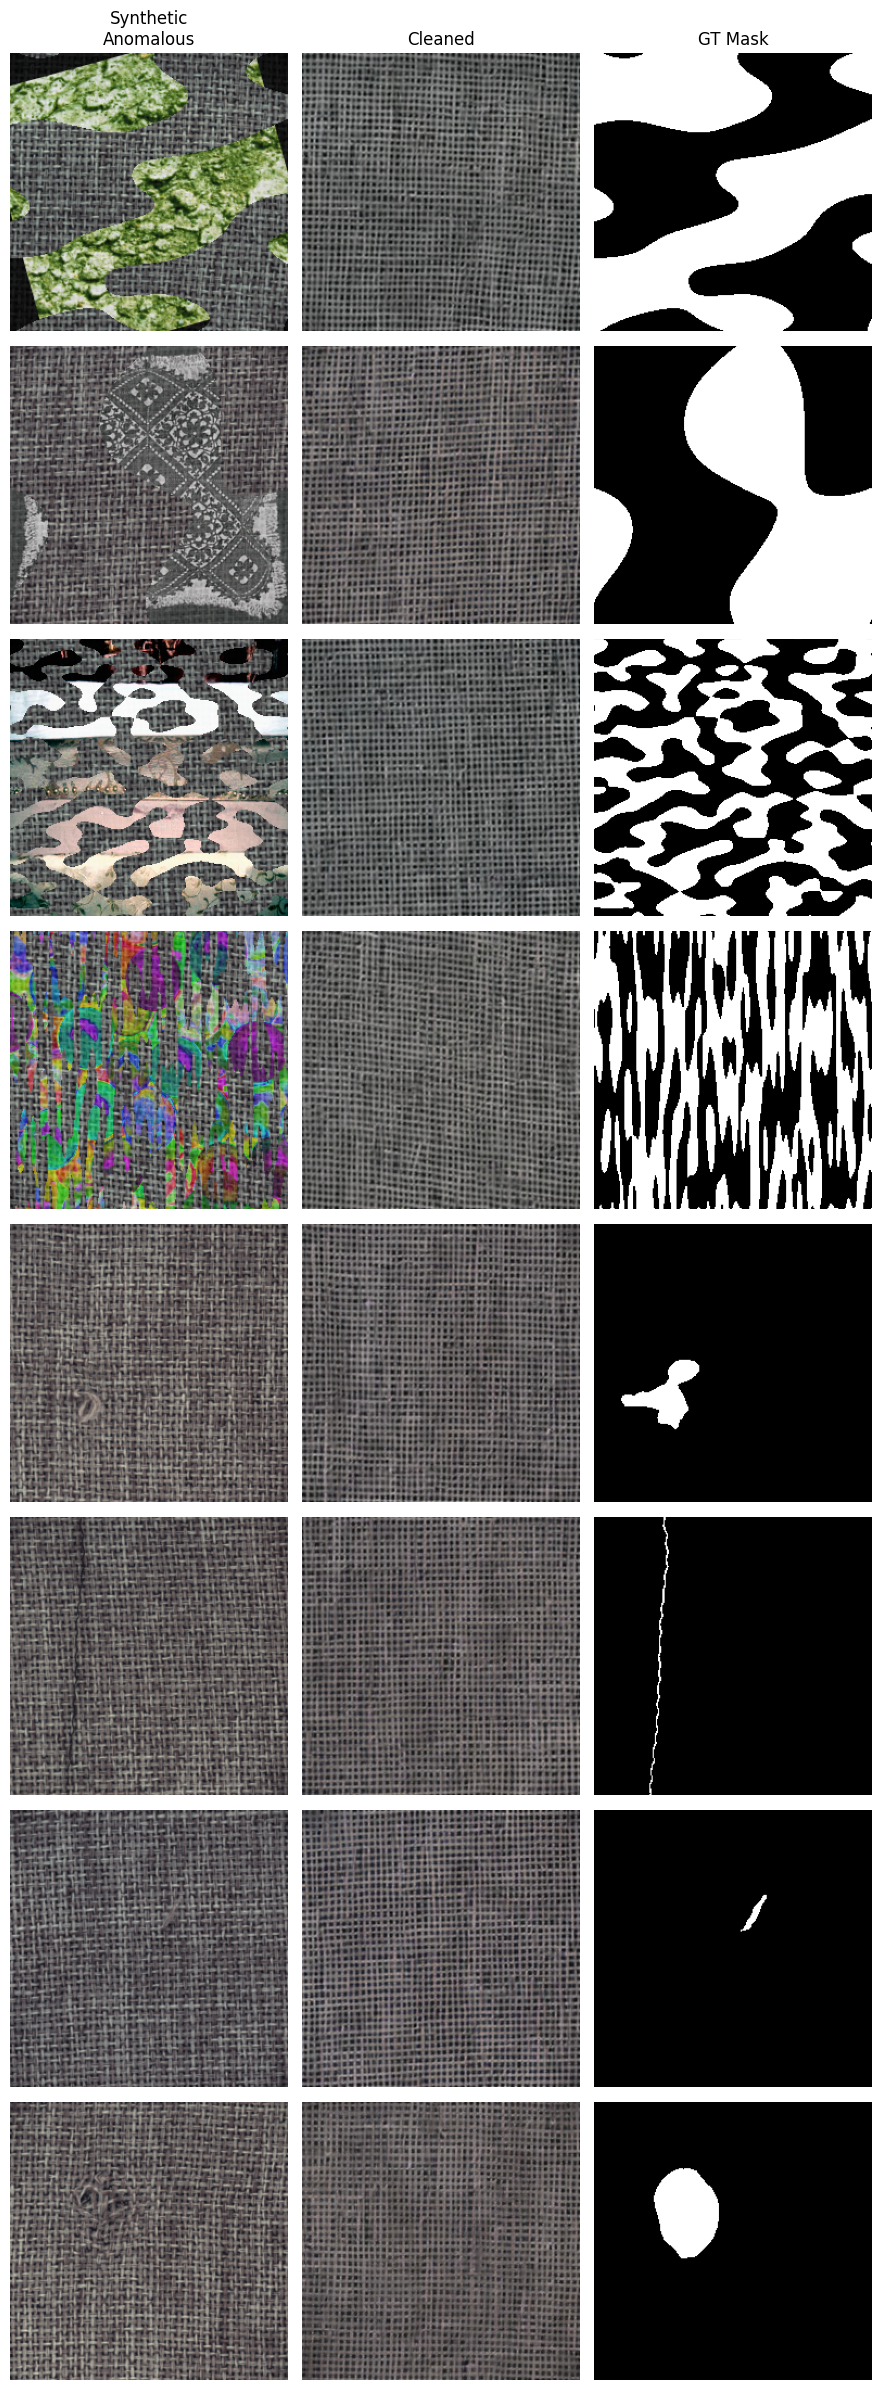

In [40]:
# ============================================================
# Cell 12b: Visualise flow model performance (simulator‑aware)
# ============================================================
"""
Displays rows of [Anomalous | Cleaned | GT Mask] for synthetic and real
defect samples.  Uses the trained conditional flow model with a
configurable ODE simulator (Euler / Heun) and number of steps.
"""
@torch.no_grad()
def clean_image(image_tensor, model, vae, scale_factor, device,
                nfe=20, gamma=0.01, simulator_type="heun"):
    lat = vae.encode(image_tensor).latent_dist.mode() * scale_factor
    cond = np.sqrt(1 - gamma) * lat + np.sqrt(gamma) * torch.randn_like(lat)

    z = torch.randn_like(lat)
    dt = 1.0 / nfe
    t_vals = torch.linspace(dt, 1.0, nfe, device=device)

    if simulator_type.lower() == "euler":
        for t in t_vals:
            torch.compiler.cudagraph_mark_step_begin()          # ★ added
            v = model(z, t.view(1, 1, 1, 1), context=cond)
            z = z + v * dt
    else:   # Heun
        for i, t in enumerate(t_vals):
            torch.compiler.cudagraph_mark_step_begin()          # ★ added
            t_tensor = t.view(1, 1, 1, 1)
            v1 = model(z, t_tensor, context=cond)
            z_euler = z + v1 * dt
            t_next = t + dt
            v2 = model(z_euler, t_next.view(1,1,1,1), context=cond) if i < nfe-1 else v1
            z = z + 0.5 * dt * (v1 + v2)

    cleaned_img = vae.decode(z / scale_factor).sample
    return cleaned_img


def visualize_flow_performance(
    model, vae, scale_factor, device,
    anomaly_gen_pixel=None,          # DiffADAnomalyGenerator (synthetic)
    good_dataset=None,               # clean images
    test_dataset=None,               # MVTecTestDataset (real defects)
    num_synthetic=3, num_real=3,
    nfe=20, gamma=0.01,              # ← changed from noise_std
    simulator_type="heun",           # "euler" or "heun"
    figsize_per_row=3.0,
):
    model.eval()
    rows_anom, rows_clean, rows_mask = [], [], []
    titles = []

    # ---------- Synthetic samples ----------
    if anomaly_gen_pixel is not None and good_dataset is not None and num_synthetic > 0:
        clean_imgs = [good_dataset[i] for i in torch.randint(0, len(good_dataset), (num_synthetic,))]
        for clean_img in clean_imgs:
            anom_img, mask = anomaly_gen_pixel.generate_pair(clean_img)
            anom_tensor = anom_img.unsqueeze(0).to(device)
            cleaned_tensor = clean_image(anom_tensor, model, vae, scale_factor, device,
                                         nfe, gamma, simulator_type)          # ← updated call
            rows_anom.append(anom_img)
            rows_clean.append(cleaned_tensor.squeeze(0).cpu())
            rows_mask.append(mask.squeeze(0))
            titles.append('Synthetic')

    # ---------- Real defect samples ----------
    if test_dataset is not None and num_real > 0:
        defects = test_dataset.get_defective_samples()
        indices = torch.randperm(len(defects))[:num_real]
        for idx in indices:
            img, mask, _ = defects[idx]
            anom_tensor = img.unsqueeze(0).to(device)
            cleaned_tensor = clean_image(anom_tensor, model, vae, scale_factor, device,
                                         nfe, gamma, simulator_type)          # ← updated call
            rows_anom.append(img)
            rows_clean.append(cleaned_tensor.squeeze(0).cpu())
            gt_mask = (mask > 0).float().squeeze(0)
            rows_mask.append(gt_mask)
            titles.append('Real defect')

    # ---------- Plot ----------
    B = len(rows_anom)
    if B == 0:
        print("No samples.")
        return
    fig, axes = plt.subplots(B, 3, figsize=(3 * figsize_per_row, B * figsize_per_row))
    if B == 1:
        axes = axes[None, :]

    for i in range(B):
        # Anomalous
        img = rows_anom[i].permute(1, 2, 0) if rows_anom[i].dim() == 3 else rows_anom[i]
        img = (img + 1) / 2
        axes[i, 0].imshow(img.clamp(0, 1))
        axes[i, 0].set_title(f"{titles[i]}\nAnomalous" if i == 0 else "")
        axes[i, 0].axis('off')

        # Cleaned
        img = rows_clean[i].permute(1, 2, 0) if rows_clean[i].dim() == 3 else rows_clean[i]
        img = (img + 1) / 2
        axes[i, 1].imshow(img.clamp(0, 1))
        axes[i, 1].set_title("Cleaned" if i == 0 else "")
        axes[i, 1].axis('off')

        # GT Mask
        mask = rows_mask[i]
        if isinstance(mask, torch.Tensor):
            mask = mask.cpu().numpy()
        axes[i, 2].imshow(mask, cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title("GT Mask" if i == 0 else "")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# ---- Usage ----
visualize_flow_performance(
    model=unet,
    vae=vae,
    scale_factor=scale_factor,
    device=device,
    anomaly_gen_pixel=anomaly_gen_pixel,
    good_dataset=good_dataset,
    test_dataset=test_dataset,
    num_synthetic=4,
    num_real=4,
    nfe=30,
    gamma=0.01,
    simulator_type="heun",
)

In [41]:
# # ============================================================
# # Wipe old segmentation data
# # ============================================================
# import shutil
# shutil.rmtree("./seg_data", ignore_errors=True)
# print("Old seg_data deleted. A fresh pre‑computation will be run.")

In [42]:
# ============================================================
# Cell 12c: Post‑flow pre‑computation (deterministic, resumable)
# ============================================================
"""
Generates exactly 10,000 anomalous and 10,000 clean triplets.
Uses a fixed random seed and saves the chosen indices to disk.
On re‑run, the same indices are loaded → only missing files are generated.
"""

import random, math, shutil, numpy as np, torch
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# ---------- Configuration ----------
NUM_ANOMALY_SUBSET = 10000
NUM_CLEAN_SUBSET   = 10000
GAMMA_FIXED = 0.01
NFE = 20
GAMMA_RANGE = (0.005, 0.015)
BATCH_SIZE = 8                    # sub‑batch for ODE simulation
RANDOM_SEED = 42

# ---------- Directories ----------
PRE_DIR  = Path("./precomputed/carpet")
SEG_DIR  = Path("./seg_data/carpet")
SEG_ANOM_DIR = SEG_DIR / "anomaly"
SEG_CLEAN_DIR = SEG_DIR / "clean"

for d in [SEG_ANOM_DIR / sub for sub in ["x_a","x_r","x_inter","mask"]] + \
         [SEG_CLEAN_DIR / sub for sub in ["x_a","x_r","x_inter"]]:
    d.mkdir(parents=True, exist_ok=True)

# ---------- Load pre‑computed data ----------
print("Loading pre‑computed latents and masks...")
clean_latents = torch.load(PRE_DIR / "clean_latents.pt", map_location='cpu')
cond_latents  = torch.load(PRE_DIR / "cond_latents.pt",  map_location='cpu')
mask_packed   = torch.load(PRE_DIR / "masks_packed.pt", map_location='cpu')
mask_shape    = torch.load(PRE_DIR / "masks_shape.pt", map_location='cpu').tolist()
clean_mmap    = np.memmap(PRE_DIR / "clean_pixels.mmap", dtype='float32',
                          mode='r', shape=(280, 3, 256, 256))

vae.eval()
unet.eval()

# ---------- Fixed random indices (saved to disk) ----------
random.seed(RANDOM_SEED)
indices_path = PRE_DIR / "seg_anom_indices.pt"
choices_path = PRE_DIR / "seg_clean_choices.pt"

if indices_path.exists():
    all_anom_indices = torch.load(indices_path).tolist()
    print(f"Loaded {len(all_anom_indices)} saved anomaly indices.")
else:
    all_anom_indices = random.sample(list(range(len(clean_latents))), NUM_ANOMALY_SUBSET)
    torch.save(torch.tensor(all_anom_indices), indices_path)
    print(f"Generated and saved {len(all_anom_indices)} anomaly indices.")

if choices_path.exists():
    clean_choices = torch.load(choices_path).tolist()
    print(f"Loaded {len(clean_choices)} saved clean choices.")
else:
    clean_choices = random.choices(list(range(len(clean_mmap))), k=NUM_CLEAN_SUBSET)
    torch.save(torch.tensor(clean_choices), choices_path)
    print(f"Generated and saved {len(clean_choices)} clean choices.")

# ---------- Helpers ----------
def unpack_mask(global_idx: int) -> torch.Tensor:
    total_pixels = int(mask_shape[1]) * int(mask_shape[2]) * int(mask_shape[3])
    bytes_per_mask = total_pixels // 8
    start_byte = global_idx * bytes_per_mask
    end_byte = start_byte + bytes_per_mask
    packed_bytes = mask_packed[start_byte:end_byte]
    flat = np.unpackbits(packed_bytes.numpy(), count=total_pixels)
    return torch.from_numpy(flat.astype(np.float32).reshape(1, 256, 256))

@torch.no_grad()
def generate_reconstructions_batch(condition_latents: torch.Tensor, device,
                                   nfe=NFE, batch_size=BATCH_SIZE):
    B = condition_latents.shape[0]
    all_x_r = []
    for start in range(0, B, batch_size):
        end = min(start + batch_size, B)
        cond = condition_latents[start:end].to(device)
        z = torch.randn_like(cond)
        dt = 1.0 / nfe
        t_vals = torch.linspace(dt, 1.0, nfe, device=device)
        with torch.amp.autocast('cuda', enabled=True):
            for t in t_vals:
                torch.compiler.cudagraph_mark_step_begin()
                t_tensor = t.view(1,1,1,1).expand(cond.shape[0], -1, -1, -1)
                v = unet(z, t_tensor, context=cond)
                z = z + v * dt
        # Decode one by one
        for i in range(z.shape[0]):
            single_z = z[i:i+1]
            single_r = vae.decode(single_z / scale_factor).sample.cpu()
            all_x_r.append(single_r)
            del single_z, single_r
            torch.cuda.empty_cache()
        del cond, z, v
        torch.cuda.empty_cache()
    return torch.cat(all_x_r, dim=0)

def tensor_to_jpeg(tensor, path, quality=95):
    arr = ((tensor.detach().squeeze(0).permute(1,2,0).numpy() + 1) / 2 * 255).astype(np.uint8)
    Image.fromarray(arr).save(path, quality=quality)

# ---------- Anomalous samples ----------
print("Checking anomalous samples...")
missing_indices = []
for idx in all_anom_indices:
    needed = [
        SEG_ANOM_DIR / "x_a"     / f"{idx}.jpg",
        SEG_ANOM_DIR / "x_r"     / f"{idx}.jpg",
        SEG_ANOM_DIR / "x_inter" / f"{idx}.jpg",
        SEG_ANOM_DIR / "mask"    / f"{idx}.png",
    ]
    if not all(p.exists() for p in needed):
        missing_indices.append(idx)

if not missing_indices:
    print("All anomalous samples are complete.")
else:
    print(f"Found {len(missing_indices)} incomplete anomalous samples. Regenerating only those...")
    for batch_start in tqdm(range(0, len(missing_indices), BATCH_SIZE), desc="Anomaly batches"):
        batch_end = min(batch_start + BATCH_SIZE, len(missing_indices))
        batch_idx = missing_indices[batch_start:batch_end]

        cond_lat_batch = cond_latents[batch_idx]
        clean_lat_batch = clean_latents[batch_idx]

        eps = torch.randn_like(cond_lat_batch)
        gamma = GAMMA_FIXED
        cond_noisy = math.sqrt(1 - gamma) * cond_lat_batch + math.sqrt(gamma) * eps

        x_r_batch = generate_reconstructions_batch(cond_noisy, device)

        # x_inter
        interp_lat = 0.5 * clean_lat_batch + 0.5 * cond_lat_batch
        x_inter_list = []
        with torch.no_grad():
            for i in range(interp_lat.shape[0]):
                single_lat = interp_lat[i:i+1].to(device)
                decoded = vae.decode(single_lat / scale_factor).sample.cpu()
                x_inter_list.append(decoded)
                del single_lat, decoded
                torch.cuda.empty_cache()
        x_inter_batch = torch.cat(x_inter_list, dim=0)

        for j, idx in enumerate(batch_idx):
            src_xa = PRE_DIR / "x_a" / f"{idx}.jpg"
            dst_xa = SEG_ANOM_DIR / "x_a" / f"{idx}.jpg"
            if not dst_xa.exists():
                shutil.copy(src_xa, dst_xa)

            tensor_to_jpeg(x_r_batch[j:j+1], SEG_ANOM_DIR / "x_r" / f"{idx}.jpg")
            tensor_to_jpeg(x_inter_batch[j:j+1], SEG_ANOM_DIR / "x_inter" / f"{idx}.jpg")

            mask = unpack_mask(idx)
            mask_np = (mask.squeeze(0).numpy() * 255).astype(np.uint8)
            Image.fromarray(mask_np).save(SEG_ANOM_DIR / "mask" / f"{idx}.png")

# ---------- Clean samples ----------
print("Checking clean samples...")
missing_clean = []
for i, c_idx in enumerate(clean_choices):
    base_name = f"clean_{c_idx}_{i}"
    needed = [
        SEG_CLEAN_DIR / "x_a"     / f"{base_name}.jpg",
        SEG_CLEAN_DIR / "x_r"     / f"{base_name}.jpg",
        SEG_CLEAN_DIR / "x_inter" / f"{base_name}.jpg",
    ]
    if not all(p.exists() for p in needed):
        missing_clean.append((i, c_idx))

if not missing_clean:
    print("All clean samples are complete.")
else:
    print(f"Found {len(missing_clean)} incomplete clean samples. Regenerating only those...")
    for batch_start in tqdm(range(0, len(missing_clean), BATCH_SIZE), desc="Clean batches"):
        batch_end = min(batch_start + BATCH_SIZE, len(missing_clean))
        batch_items = missing_clean[batch_start:batch_end]
        choices   = [c_idx for _, c_idx in batch_items]
        rep_offs  = [rep_off for rep_off, _ in batch_items]

        clean_imgs_batch = []
        for c_idx in choices:
            img_np = clean_mmap[c_idx]
            clean_imgs_batch.append(torch.from_numpy(img_np.copy()).float().unsqueeze(0))
        clean_imgs_batch = torch.cat(clean_imgs_batch, dim=0).to(device)

        clean_lats = vae.encode(clean_imgs_batch).latent_dist.mode() * scale_factor
        clean_lats = clean_lats.cpu()

        gammas = torch.tensor([random.uniform(*GAMMA_RANGE) for _ in range(len(choices))],
                              device='cpu').view(-1,1,1,1)
        eps = torch.randn_like(clean_lats)
        cond_noisy = torch.sqrt(1 - gammas) * clean_lats + torch.sqrt(gammas) * eps

        x_r_batch = generate_reconstructions_batch(cond_noisy, device)

        interp_lat = 0.5 * clean_lats + 0.5 * cond_noisy
        x_inter_list = []
        with torch.no_grad():
            for i in range(interp_lat.shape[0]):
                single_lat = interp_lat[i:i+1].to(device)
                decoded = vae.decode(single_lat / scale_factor).sample.cpu()
                x_inter_list.append(decoded)
                del single_lat, decoded
                torch.cuda.empty_cache()
        x_inter_batch = torch.cat(x_inter_list, dim=0)

        for j, (c_idx, rep_off) in enumerate(zip(choices, rep_offs)):
            x_a_tensor = clean_imgs_batch[j:j+1].cpu()
            base_name = f"clean_{c_idx}_{rep_off}"
            tensor_to_jpeg(x_a_tensor, SEG_CLEAN_DIR / "x_a" / f"{base_name}.jpg")
            tensor_to_jpeg(x_r_batch[j:j+1], SEG_CLEAN_DIR / "x_r" / f"{base_name}.jpg")
            tensor_to_jpeg(x_inter_batch[j:j+1], SEG_CLEAN_DIR / "x_inter" / f"{base_name}.jpg")

print("\n✅ Pre‑computation complete!")
print(f"Anomaly data: {SEG_ANOM_DIR}")
print(f"Clean data:   {SEG_CLEAN_DIR}")

Loading pre‑computed latents and masks...
Loaded 10000 saved anomaly indices.
Loaded 10000 saved clean choices.
Checking anomalous samples...
All anomalous samples are complete.
Checking clean samples...
All clean samples are complete.

✅ Pre‑computation complete!
Anomaly data: seg_data/carpet/anomaly
Clean data:   seg_data/carpet/clean


In [43]:
# ============================================================
# Cell 13: Exact DiffAD DiscriminativeSubNetwork (DiffAD segmentation head)
# ============================================================
def weights_init(m):
    """Conv → N(0,0.02), BatchNorm → N(1,0.02), bias=0."""
    if isinstance(m, nn.Conv2d):
        m.weight.data.normal_(0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

class DiscriminativeSubNetwork(nn.Module):
    def __init__(self, in_channels=9, out_channels=2, base_channels=64):
        super().__init__()
        self.encoder = EncoderDiscriminative(in_channels, base_channels)
        self.decoder = DecoderDiscriminative(base_channels, out_channels=out_channels)

    def forward(self, x):
        b1, b2, b3, b4, b5, b6 = self.encoder(x)
        return self.decoder(b1, b2, b3, b4, b5, b6)

class EncoderDiscriminative(nn.Module):
    def __init__(self, in_channels, base_width):
        super().__init__()
        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True))
        self.block1 = block(in_channels, base_width)
        self.mp1 = nn.MaxPool2d(2)
        self.block2 = block(base_width, base_width*2)
        self.mp2 = nn.MaxPool2d(2)
        self.block3 = block(base_width*2, base_width*4)
        self.mp3 = nn.MaxPool2d(2)
        self.block4 = block(base_width*4, base_width*8)
        self.mp4 = nn.MaxPool2d(2)
        self.block5 = block(base_width*8, base_width*8)
        self.mp5 = nn.MaxPool2d(2)
        self.block6 = block(base_width*8, base_width*8)

    def forward(self, x):
        b1 = self.block1(x)
        b2 = self.block2(self.mp1(b1))
        b3 = self.block3(self.mp2(b2))
        b4 = self.block4(self.mp3(b3))
        b5 = self.block5(self.mp4(b4))
        b6 = self.block6(self.mp5(b5))
        return b1, b2, b3, b4, b5, b6

class DecoderDiscriminative(nn.Module):
    def __init__(self, base_width, out_channels=1):
        super().__init__()
        def up_block(in_ch, out_ch):
            return nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                                 nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True))
        def db_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True))
        self.up_b = up_block(base_width*8, base_width*8)
        self.db_b = db_block(base_width*(8+8), base_width*8)
        self.up1 = up_block(base_width*8, base_width*4)
        self.db1 = db_block(base_width*(4+8), base_width*4)
        self.up2 = up_block(base_width*4, base_width*2)
        self.db2 = db_block(base_width*(2+4), base_width*2)
        self.up3 = up_block(base_width*2, base_width)
        self.db3 = db_block(base_width*(2+1), base_width)
        self.up4 = up_block(base_width, base_width)
        self.db4 = db_block(base_width*2, base_width)
        self.fin_out = nn.Conv2d(base_width, out_channels, 3, padding=1)

    def forward(self, b1, b2, b3, b4, b5, b6):
        up_b = self.up_b(b6)
        cat_b = torch.cat((up_b, b5), dim=1)
        db_b = self.db_b(cat_b)
        up1 = self.up1(db_b)
        cat1 = torch.cat((up1, b4), dim=1)
        db1 = self.db1(cat1)
        up2 = self.up2(db1)
        cat2 = torch.cat((up2, b3), dim=1)
        db2 = self.db2(cat2)
        up3 = self.up3(db2)
        cat3 = torch.cat((up3, b2), dim=1)
        db3 = self.db3(cat3)
        up4 = self.up4(db3)
        cat4 = torch.cat((up4, b1), dim=1)
        db4 = self.db4(cat4)
        return self.fin_out(db4)

In [44]:
# ============================================================
# Cell 14: FocalLoss (simplified, robust)
# ============================================================
class FocalLoss(nn.Module):
    """
    Focal Loss for binary segmentation.

    Expected inputs:
      - logits : (B, 2, H, W) raw scores (before softmax)
      - target : (B, 1, H, W) or (B, H, W) with values in {0, 1}

    The loss is computed per pixel, exactly as in the DiffAD paper.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, target):
        # logits: (B, 2, H, W) – raw scores for background (0) and anomaly (1)
        # target: (B, 1, H, W) or (B, H, W) with 0/1
        if target.dim() == 4 and target.shape[1] == 1:
            target = target.squeeze(1)          # -> (B, H, W)
        target = target.long()

        # Standard cross‑entropy loss with reduction='none' gives per‑pixel loss
        ce_loss = F.cross_entropy(logits, target, reduction='none')  # (B, H, W)

        # Probability of the correct class
        pt = torch.exp(-ce_loss)

        # Focal weighting
        focal_weight = (1 - pt) ** self.gamma

        # Alpha balancing (alpha for foreground, 1-alpha for background)
        alpha_t = torch.where(target == 1, self.alpha, 1.0 - self.alpha)

        loss = alpha_t * focal_weight * ce_loss

        return loss.mean()
        
# Original DiffAD FocalLoss (allegedly!)
# class FocalLoss(nn.Module):
#     def __init__(self, apply_nonlin=None, alpha=0.25, gamma=2, balance_index=0, smooth=1e-5, size_average=True):
#         super().__init__()
#         self.apply_nonlin = apply_nonlin
#         self.alpha = alpha
#         self.gamma = gamma
#         self.balance_index = balance_index
#         self.smooth = smooth
#         self.size_average = size_average

#     def forward(self, logit, target):
#         if self.apply_nonlin is not None:
#             logit = self.apply_nonlin(logit)
#         num_class = logit.shape[1]
#         if logit.dim() > 2:
#             logit = logit.view(logit.size(0), logit.size(1), -1).permute(0,2,1).contiguous().view(-1, logit.size(-1))
#         target = torch.squeeze(target, 1).view(-1, 1)
#         alpha = self.alpha
#         if alpha is None:
#             alpha = torch.ones(num_class, 1)
#         elif isinstance(alpha, (list, np.ndarray)):
#             assert len(alpha) == num_class
#             alpha = torch.FloatTensor(alpha).view(num_class, 1) / alpha.sum()
#         elif isinstance(alpha, float):
#             alpha = torch.ones(num_class, 1) * (1 - self.alpha)
#             alpha[self.balance_index] = self.alpha
#         if alpha.device != logit.device:
#             alpha = alpha.to(logit.device)
#         idx = target.cpu().long()
#         one_hot = torch.FloatTensor(target.size(0), num_class).zero_().scatter_(1, idx, 1).to(logit.device)
#         if self.smooth:
#             one_hot = one_hot.clamp(self.smooth/(num_class-1), 1.0-self.smooth)
#         pt = (one_hot * logit).sum(1) + self.smooth
#         logpt = pt.log()
#         gamma = self.gamma
#         alpha = alpha[idx].squeeze()
#         loss = -1 * alpha * torch.pow((1-pt), gamma) * logpt
#         if self.size_average:
#             return loss.mean()
#         return loss.sum()

In [45]:
# ============================================================
# Cell 15a: SegmentationDataset – load triplets + masks
# ============================================================
"""
Loads anomaly and clean triplets saved by Cell 12c and returns
(input_tensor, mask_tensor) for the discriminative segmentation
network.

Optimisation: uses ``torchvision.io.read_image`` instead of PIL,
which decodes JPEG/PNG directly to a tensor via libjpeg‑turbo,
avoiding a Python‑object → numpy → tensor round‑trip.  Images were
saved at 256×256, so no resizing is performed.

Each sample consists of three 3‑channel images:
  - x_a  (anomalous input, or clean original for clean samples)
  - x_r  (rectified flow reconstruction)
  - x_inter (latent interpolation)
concatenated along the channel dimension → a 9‑channel input.

For anomalous samples the mask is loaded from a PNG and normalised
to [0,1].  Clean samples receive an all‑zero mask.
"""

from pathlib import Path
import torch
from torch.utils.data import Dataset
from torchvision.io import read_image

class SegmentationDataset(Dataset):
    def __init__(self, anomaly_root, clean_root, image_size=256):
        """
        Parameters
        ----------
        anomaly_root : Path
            Directory with subdirectories x_a, x_r, x_inter, mask.
        clean_root : Path
            Directory with subdirectories x_a, x_r, x_inter.
        image_size : int
            Spatial size of the images (used only for the zero‑mask
            shape of clean samples).
        """
        self.image_size = image_size
        self.samples = []

        # ---------- Anomalous samples ----------
        anom_xa_dir = Path(anomaly_root) / "x_a"
        for img_path in sorted(anom_xa_dir.glob("*.jpg")):
            idx = img_path.stem                     # e.g. "12345"
            self.samples.append((
                str(img_path),                                    # x_a
                str(Path(anomaly_root) / "x_r" / f"{idx}.jpg"),   # x_r
                str(Path(anomaly_root) / "x_inter" / f"{idx}.jpg"), # x_inter
                str(Path(anomaly_root) / "mask" / f"{idx}.png"),   # mask
                True                                              # has anomaly
            ))

        # ---------- Clean samples ----------
        clean_xa_dir = Path(clean_root) / "x_a"
        for img_path in sorted(clean_xa_dir.glob("*.jpg")):
            base = img_path.stem                     # e.g. "clean_42_0"
            self.samples.append((
                str(img_path),                                       # x_a
                str(Path(clean_root) / "x_r" / f"{base}.jpg"),       # x_r
                str(Path(clean_root) / "x_inter" / f"{base}.jpg"),   # x_inter
                None,                                                 # no mask
                False                                                 # clean (no anomaly)
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        xa_path, xr_path, xi_path, mask_path, has_anomaly = self.samples[idx]

        # read_image returns uint8 (3,H,W) in [0,255] → convert to [-1,1]
        x_a  = read_image(xa_path).float().div_(127.5).sub_(1.0)
        x_r  = read_image(xr_path).float().div_(127.5).sub_(1.0)
        x_inter = read_image(xi_path).float().div_(127.5).sub_(1.0)

        # Concatenate → (9, H, W)
        input_tensor = torch.cat([x_a, x_r, x_inter], dim=0)

        # Mask
        if has_anomaly and mask_path is not None:
            mask = read_image(mask_path).float().div_(255.0)   # → [0,1]
        else:
            mask = torch.zeros(1, self.image_size, self.image_size, dtype=torch.float32)

        return input_tensor, mask

In [46]:
# ============================================================
# Cleanup: free GPU memory taken by the flow model & VAE
# ============================================================
import gc

# Clear torch.compile's CUDA graph cache first
torch._dynamo.reset()

if 'unet' in dir():
    del unet
if 'vae' in dir():
    del vae
if 'path' in dir():
    del path
if 'gpu_sampler' in dir():
    del gpu_sampler
if 'trainer' in dir():
    del trainer

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print("Cleanup complete.")
report_gpu_memory()

Cleanup complete.
GPU total: 15.64 GB
Allocated:  0.339 GB
Reserved:   0.445 GB
Free (approx): 15.192 GB


In [47]:
# # ============================================================
# # Delete old segmentation checkpoints (start fresh)
# # ============================================================
# import shutil, os

# ckpt_dir = "./checkpoints/seg_carpet"
# if os.path.isdir(ckpt_dir):
#     shutil.rmtree(ckpt_dir)
#     print("Old segmentation checkpoints deleted.")
# else:
#     print("No old checkpoints found.")

In [48]:
# ============================================================
# Cell 15b: Training the discriminative segmentation network
# ============================================================
# Speed‑ups applied:
#   - RAM caching (if enough CPU RAM) → zero disk I/O after 1ˢᵗ epoch
#   - Tensor Core hints (TF32 + high matmul precision)
#   - Optional torch.compile (off by default – test carefully)
#   - torch.inference_mode during validation
#   - Mixed precision (AMP), micro‑batch 16, accumulation 4 → effective batch 64
#   - Resume & early stopping
#   - Fallback to 4‑worker disk loading if RAM insufficient
#   - Uses raw logits for FocalLoss (no softmax)
# ============================================================

import torch, torch.optim as optim, os, time
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm
from pathlib import Path

# ---------- Tensor Core hints ----------
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision('high')

# ---------- Configuration ----------
MICRO_BATCH_SIZE = 16           # fits in GPU memory
ACCUM_STEPS      = 4            # effective batch = 16 * 4 = 64
EPOCHS           = 50            # enough for this task
MILESTONES       = [20, 23]      # 80% / 90% of 25
EARLY_STOP_PATIENCE = 3         # stop after 3 checks without improvement
GAMMA            = 0.2
USE_AMP          = True
USE_COMPILE      = False
CHECKPOINT_DIR   = "./checkpoints/seg_carpet"
CHECKPOINT_EVERY = 25
VAL_EVERY        = 4
VAL_SPLIT        = 0.1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ---------- Load dataset ----------
dataset = SegmentationDataset(
    anomaly_root=Path("./seg_data/carpet/anomaly"),
    clean_root=Path("./seg_data/carpet/clean")
)
print(f"Total samples: {len(dataset)}", flush=True)

val_size = int(VAL_SPLIT * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}", flush=True)

# ---------- Optional RAM caching ----------
try:
    import psutil
    RAM_OK = True
except ImportError:
    RAM_OK = False
    print("psutil not installed – skipping RAM cache check", flush=True)

class CachedDataset(Dataset):
    """Wrap a dataset and cache all (input, mask) in CPU RAM as float16."""
    def __init__(self, dataset):
        print("Caching dataset in RAM...", flush=True)
        self.inputs = []
        self.masks  = []
        for i in tqdm(range(len(dataset)), desc="Caching"):
            inp, mask = dataset[i]
            self.inputs.append(inp.half())
            self.masks.append(mask)
        print(f"Cached {len(self.inputs)} samples. "
              f"RAM ≈ {len(self.inputs)*9*256*256*2/1e9:.1f} GB", flush=True)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx].float(), self.masks[idx]

use_cache = False
if RAM_OK:
    available_gb = psutil.virtual_memory().available / 1e9
    required_gb  = len(train_dataset) * 9 * 256 * 256 * 2 / 1e9   # float16
    if available_gb > required_gb * 1.5:
        use_cache = True

if use_cache:
    print(f"RAM available {available_gb:.1f} GB, need ~{required_gb:.1f} GB. Caching.", flush=True)
    train_dataset = CachedDataset(train_dataset)
    val_dataset   = CachedDataset(val_dataset)
    dl_workers = 0
    dl_persistent = False
    dl_prefetch = None
else:
    if RAM_OK:
        print(f"RAM available {available_gb:.1f} GB, need ~{required_gb:.1f} GB. "
              "Using disk loading.", flush=True)
    dl_workers = 4
    dl_persistent = True
    dl_prefetch = 2

# ---------- DataLoaders (batch size = micro_batch) ----------
train_loader = DataLoader(
    train_dataset, batch_size=MICRO_BATCH_SIZE, shuffle=True,
    num_workers=dl_workers, pin_memory=True, drop_last=True,
    persistent_workers=dl_persistent, prefetch_factor=dl_prefetch,
)
val_loader = DataLoader(
    val_dataset, batch_size=MICRO_BATCH_SIZE, shuffle=False,
    num_workers=dl_workers, pin_memory=True,
    persistent_workers=dl_persistent, prefetch_factor=dl_prefetch,
)

# ---------- Model, loss, optimizer, scheduler ----------
model_seg = DiscriminativeSubNetwork(in_channels=9, out_channels=2).to(DEVICE)
# Quick shape sanity check
dummy = torch.randn(2, 9, 256, 256).to(DEVICE)
with torch.no_grad():
    out = model_seg(dummy)
print(f"Model output shape: {out.shape}")   # must be [2, 2, 256, 256]
assert out.shape[1] == 2, f"Expected 2 output channels, got {out.shape[1]}"
model_seg.apply(weights_init)

if USE_COMPILE and hasattr(torch, 'compile'):
    print("Applying torch.compile to segmentation model (reduce-overhead).", flush=True)
    model_seg = torch.compile(model_seg, mode='reduce-overhead', fullgraph=False)

criterion = FocalLoss()   # raw logits
optimizer = optim.Adam(model_seg.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=MILESTONES, gamma=GAMMA)
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

# ---------- Resume & early stopping ----------
best_val_loss = float('inf')
start_epoch   = 1
epochs_no_improve = 0

resume_path = os.path.join(CHECKPOINT_DIR, "seg_best.pt")
if os.path.exists(resume_path):
    ckpt = torch.load(resume_path, map_location=DEVICE)
    model_seg.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    best_val_loss = ckpt['val_loss']
    epochs_no_improve = ckpt.get('epochs_no_improve', 0)
    print(f"Resumed from epoch {ckpt['epoch']}, best val_loss={best_val_loss:.4f}", flush=True)

# ---------- Quick timing estimate (only if fresh start) ----------
if start_epoch == 1:
    model_seg.train()
    torch.cuda.synchronize()
    t0 = time.time()
    # run a few accumulation cycles to estimate
    for i, (inputs, masks) in enumerate(train_loader):
        if i >= ACCUM_STEPS * 5: break   # 5 effective batches
        inputs, masks = inputs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True).long()
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            outputs = model_seg(inputs)
            loss = criterion(outputs, masks) / ACCUM_STEPS
        scaler.scale(loss).backward()
        # optimizer step after every ACCUM_STEPS micro‑batches
        if (i + 1) % ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
    torch.cuda.synchronize()
    elapsed = time.time() - t0
    eff_batches = 5
    secs_per_eff_batch = elapsed / eff_batches
    eff_batches_per_epoch = len(train_dataset) // (MICRO_BATCH_SIZE * ACCUM_STEPS)
    secs_per_epoch = secs_per_eff_batch * eff_batches_per_epoch
    print(f"Estimated time per epoch: {secs_per_epoch:.1f}s  ({secs_per_epoch/60:.1f} min)", flush=True)
    print(f"Estimated total ({EPOCHS} epochs): {secs_per_epoch * EPOCHS / 3600:.1f} h", flush=True)

# ---------- Validation helper ----------
@torch.inference_mode()
def compute_val_loss(model, loader, device, use_amp):
    model.eval()
    total_loss = 0.0
    count = 0
    for inputs, masks in loader:
        inputs, masks = inputs.to(device, non_blocking=True), masks.to(device, non_blocking=True).long()
        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(inputs)
            loss = criterion(outputs, masks)
        total_loss += loss.item()
        count += 1
    return total_loss / count

# ---------- Main training loop ----------
for epoch in range(start_epoch, EPOCHS + 1):
    model_seg.train()
    total_loss = 0.0
    micro_count = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    for inputs, masks in pbar:
        inputs, masks = inputs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True).long()
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            outputs = model_seg(inputs)
            loss = criterion(outputs, masks) / ACCUM_STEPS
        scaler.scale(loss).backward()
        total_loss += loss.item() * ACCUM_STEPS   # accumulate unscaled
        micro_count += 1

        # Optimizer step after every ACCUM_STEPS micro‑batches
        if micro_count % ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            pbar.set_postfix(loss=total_loss / micro_count)

    # Handle any leftover micro‑batches (should not happen with drop_last=True)
    if micro_count % ACCUM_STEPS != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    avg_train_loss = total_loss / micro_count
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    log_msg = f"Epoch {epoch:3d}/{EPOCHS} | train_loss: {avg_train_loss:.4f} | lr: {current_lr:.2e}"

    if epoch % VAL_EVERY == 0 or epoch == EPOCHS:
        val_loss = compute_val_loss(model_seg, val_loader, DEVICE, USE_AMP)
        log_msg += f" | val_loss: {val_loss:.4f}"
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({
                'epoch': epoch, 'model_state_dict': model_seg.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_loss': val_loss, 'train_loss': avg_train_loss,
                'epochs_no_improve': epochs_no_improve,
            }, os.path.join(CHECKPOINT_DIR, "seg_best.pt"))
            log_msg += " (best)"
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOP_PATIENCE:
                print(log_msg, flush=True)
                print("Early stopping.", flush=True)
                break

    if epoch % CHECKPOINT_EVERY == 0:
        torch.save({
            'epoch': epoch, 'model_state_dict': model_seg.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': avg_train_loss, 'epochs_no_improve': epochs_no_improve,
        }, os.path.join(CHECKPOINT_DIR, f"seg_epoch_{epoch}.pt"))

    print(log_msg, flush=True)

torch.save(model_seg.state_dict(), os.path.join(CHECKPOINT_DIR, "seg_final.pt"))
print("Training complete. Final model saved.", flush=True)

Total samples: 20000
Train: 18000, Val: 2000
RAM available 28.4 GB, need ~21.2 GB. Using disk loading.
Model output shape: torch.Size([2, 2, 256, 256])
Resumed from epoch 25, best val_loss=0.0024
Training complete. Final model saved.


In [54]:
# ============================================================
# Reload VAE for evaluation (Cell 16)
# ============================================================
from diffusers import AutoencoderKL

# Reload the same VAE used during flow‑model training
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
scale_factor = vae.config.scaling_factor    # 0.18215
print("VAE reloaded for evaluation.")

VAE reloaded for evaluation.


In [55]:
# ============================================================
# Cell 16: DiffAD‑style evaluation (Heun integrator, tuneable)
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score

# ================= 1. Helper functions =================
def anomaly_score_map(image_tensor, flow_model, seg_model, vae, scale_factor,
                      device, nfe=50, gamma=0.01):
    """
    Produce the raw (un‑smoothed) anomaly probability map for one image.
    Uses Heun integration (2nd order) for higher fidelity.
    gamma: noise level (variance‑preserving), matching training.
    """
    # Encode test image
    z_anom = vae.encode(image_tensor).latent_dist.mode() * scale_factor

    # Conditioning – variance‑preserving
    cond = np.sqrt(1 - gamma) * z_anom + np.sqrt(gamma) * torch.randn_like(z_anom)

    # Heun ODE solver (same as clean_image)
    z = torch.randn_like(z_anom)
    dt = 1.0 / nfe
    t_vals = torch.linspace(dt, 1.0, nfe, device=device)

    for i, t in enumerate(t_vals):
        torch.compiler.cudagraph_mark_step_begin()
        t_tensor = t.view(1, 1, 1, 1)
        v1 = flow_model(z, t_tensor, context=cond)
        z_euler = z + v1 * dt
        t_next = t + dt
        if i < nfe - 1:
            v2 = flow_model(z_euler, t_next.view(1, 1, 1, 1), context=cond)
        else:
            v2 = v1
        z = z + 0.5 * dt * (v1 + v2)

    z_cleaned = z

    # Decode
    cleaned_img = vae.decode(z_cleaned / scale_factor).sample          # (1,3,H,W)
    z_interp = 0.5 * z_cleaned + 0.5 * z_anom
    interp_img = vae.decode(z_interp / scale_factor).sample            # (1,3,H,W)
    anomalous_img = image_tensor

    # Concatenate in the SAME order as training: x_a, x_r, x_inter
    joined = torch.cat((anomalous_img.detach(), cleaned_img.detach(),
                        interp_img.detach()), dim=1)   # (1,9,256,256)

    logits = seg_model(joined)
    probs = torch.softmax(logits, dim=1)
    anomaly_prob = probs[:, 1:2, :, :]          # (1,1,256,256)
    return anomaly_prob

# ================= 2. Evaluation loop =================
def evaluate_diffad_metrics(flow_model, seg_model, vae, scale_factor,
                            test_dataset, device, nfe=50, gamma=0.01):
    """
    Compute image‑level and pixel‑level AUROC / AP exactly as DiffAD does.
    """
    flow_model.eval()
    seg_model.eval()

    image_scores = []
    image_labels = []
    all_pixel_preds = []
    all_pixel_gts   = []

    for idx in tqdm(range(len(test_dataset)), desc="Evaluating"):
        img, mask, _ = test_dataset[idx]
        img = img.unsqueeze(0).to(device)
        mask = mask.to(device)

        has_anomaly = mask.max() > -1.0
        image_labels.append(int(has_anomaly))

        gt_binary = (mask > 0).float()

        anomaly_prob = anomaly_score_map(
            img, flow_model, seg_model, vae, scale_factor, device, nfe, gamma
        )

        # Image‑level score: max of smoothed map (21×21 average pooling)
        smoothed = F.avg_pool2d(anomaly_prob, kernel_size=21, stride=1,
                                padding=21//2)
        image_score = smoothed.max().item()
        image_scores.append(image_score)

        all_pixel_preds.append(anomaly_prob.detach().flatten().cpu().numpy())
        all_pixel_gts.append(gt_binary.detach().flatten().cpu().numpy())

    image_scores = np.array(image_scores)
    image_labels = np.array(image_labels)
    pixel_preds = np.concatenate(all_pixel_preds)
    pixel_gts   = np.concatenate(all_pixel_gts)

    img_auroc = roc_auc_score(image_labels, image_scores)
    img_ap    = average_precision_score(image_labels, image_scores)
    pixel_auroc = roc_auc_score(pixel_gts, pixel_preds)
    pixel_ap    = average_precision_score(pixel_gts, pixel_preds)

    return {
        'img_auroc': img_auroc,
        'img_ap':    img_ap,
        'pixel_auroc': pixel_auroc,
        'pixel_ap':    pixel_ap,
    }

# ================= 3. Run evaluation & gamma sweep =================

# Load models (unchanged)
checkpoint = torch.load("./checkpoints/cond_unet_carpet/unet_best.pt", map_location=device)
unet.load_state_dict(checkpoint["model_state"])
unet.eval()

seg_checkpoint = torch.load("./checkpoints/seg_carpet/seg_best.pt", map_location=device)
model_seg.load_state_dict(seg_checkpoint['model_state_dict'])
model_seg.eval()

# Evaluate with suggested parameters
print("Evaluating with nfe=50, gamma=0.01 …")
results = evaluate_diffad_metrics(
    flow_model=unet, seg_model=model_seg, vae=vae,
    scale_factor=scale_factor, test_dataset=test_dataset,
    device=device, nfe=50, gamma=0.01
)
print(f"\nImage‑level AUROC: {results['img_auroc']:.4f}")
print(f"Image‑level AP:    {results['img_ap']:.4f}")
print(f"Pixel‑level AUROC: {results['pixel_auroc']:.4f}")
print(f"Pixel‑level AP:    {results['pixel_ap']:.4f}")

# Small gamma sweep (run after first evaluation)
print("\nGamma sweep (nfe=50):")
for g in [0.005, 0.01, 0.02, 0.05]:
    res = evaluate_diffad_metrics(
        flow_model=unet, seg_model=model_seg, vae=vae,
        scale_factor=scale_factor, test_dataset=test_dataset,
        device=device, nfe=50, gamma=g
    )
    print(f"gamma={g:.3f} | img_AUROC={res['img_auroc']:.4f} | pixel_AP={res['pixel_ap']:.4f}")

Evaluating with nfe=50, gamma=0.01 …


Evaluating:   0%|          | 0/117 [00:00<?, ?it/s]AUTOTUNE addmm(1x256, 1x64, 64x256)
  bias_addmm 0.0051 ms 100.0% 
  addmm 0.0069 ms 72.8% 
SingleProcess AUTOTUNE benchmarking takes 0.2459 seconds and 0.0002 seconds precompiling for 2 choices
AUTOTUNE addmm(1x256, 1x256, 256x256)
  bias_addmm 0.0067 ms 100.0% 
  addmm 0.0085 ms 78.6% 
SingleProcess AUTOTUNE benchmarking takes 0.2166 seconds and 0.0002 seconds precompiling for 2 choices
AUTOTUNE addmm(1x128, 1x256, 256x128)
  bias_addmm 0.0061 ms 100.0% 
  addmm 0.0078 ms 78.2% 
SingleProcess AUTOTUNE benchmarking takes 0.2169 seconds and 0.0003 seconds precompiling for 2 choices
AUTOTUNE addmm(1x512, 1x256, 256x512)
  bias_addmm 0.0082 ms 100.0% 
  addmm 0.0102 ms 80.3% 
SingleProcess AUTOTUNE benchmarking takes 0.2167 seconds and 0.0003 seconds precompiling for 2 choices
Evaluating: 100%|██████████| 117/117 [05:24<00:00,  2.77s/it] 



Image‑level AUROC: 0.7841
Image‑level AP:    0.9277
Pixel‑level AUROC: 0.8985
Pixel‑level AP:    0.4388

Gamma sweep (nfe=50):


Evaluating: 100%|██████████| 117/117 [01:51<00:00,  1.05it/s]


gamma=0.005 | img_AUROC=0.8042 | pixel_AP=0.4294


...

gamma=0.010 | img_AUROC=0.7929 | pixel_AP=0.4398


Evaluating: 100%|██████████| 117/117 [01:51<00:00,  1.05it/s]


gamma=0.020 | img_AUROC=0.7805 | pixel_AP=0.4525


Evaluating: 100%|██████████| 117/117 [01:51<00:00,  1.05it/s]


gamma=0.050 | img_AUROC=0.7982 | pixel_AP=0.4484


In [56]:
# ============================================================
# Cell 16 – Euler evaluation (same as training)
# ============================================================

def anomaly_score_map(image_tensor, flow_model, seg_model, vae, scale_factor,
                      device, nfe=20, gamma=0.01):
    # Encode
    z_anom = vae.encode(image_tensor).latent_dist.mode() * scale_factor
    # Conditioning
    cond = np.sqrt(1 - gamma) * z_anom + np.sqrt(gamma) * torch.randn_like(z_anom)

    # Euler ODE (matching training)
    z = torch.randn_like(z_anom)
    dt = 1.0 / nfe
    t_vals = torch.linspace(dt, 1.0, nfe, device=device)
    for t in t_vals:
        torch.compiler.cudagraph_mark_step_begin()
        v = flow_model(z, t.view(1, 1, 1, 1), context=cond)
        z = z + v * dt
    z_cleaned = z

    # Decode & concatenate (same order as training)
    cleaned_img = vae.decode(z_cleaned / scale_factor).sample
    z_interp = 0.5 * z_cleaned + 0.5 * z_anom
    interp_img = vae.decode(z_interp / scale_factor).sample
    anomalous_img = image_tensor

    joined = torch.cat((anomalous_img.detach(), cleaned_img.detach(),
                        interp_img.detach()), dim=1)   # x_a, x_r, x_inter
    logits = seg_model(joined)
    probs = torch.softmax(logits, dim=1)
    return probs[:, 1:2, :, :]          # anomaly probability map

# … the rest of evaluate_diffad_metrics stays exactly the same …

# ---- Run evaluation ----
checkpoint = torch.load("./checkpoints/cond_unet_carpet/unet_best.pt", map_location=device)
unet.load_state_dict(checkpoint["model_state"]); unet.eval()

seg_ckpt = torch.load("./checkpoints/seg_carpet/seg_best.pt", map_location=device)
model_seg.load_state_dict(seg_ckpt['model_state_dict']); model_seg.eval()

print("Evaluating (Euler, nfe=20, gamma=0.01) …")
res = evaluate_diffad_metrics(unet, model_seg, vae, scale_factor,
                               test_dataset, device, nfe=20, gamma=0.01)
print(f"Image‑level AUROC: {res['img_auroc']:.4f}")
print(f"Image‑level AP:    {res['img_ap']:.4f}")
print(f"Pixel‑level AUROC: {res['pixel_auroc']:.4f}")
print(f"Pixel‑level AP:    {res['pixel_ap']:.4f}")

Evaluating (Euler, nfe=20, gamma=0.01) …


Evaluating: 100%|██████████| 117/117 [01:02<00:00,  1.89it/s]


Image‑level AUROC: 0.7773
Image‑level AP:    0.9247
Pixel‑level AUROC: 0.9020
Pixel‑level AP:    0.4522
